# FHIRScan — DIZ-Vergleichsanalyse

Vergleicht die Profiling-Outputs von bis zu **6 Datenintegrationszentren (DIZ)**.  
Jedes DIZ entspricht einem Ordner, den `main.py` erzeugt hat.

**Struktur:**
1. Datensatz-Übersicht (Ressourcenzahlen, Abdeckung)
2. Datenqualität (Patient/Encounter-Linkage)
3. Kardinalitätsvergleich
4. Vollständigkeitsanalyse (Presence Rates) — Heatmaps, Abweichungen vom Mittelwert, Vollständigkeitsklassen (eigener & gemeinsamer Nenner)
5. Größte Abweichungen zwischen DIZ
6. Wertverteilung für kodierte Felder
7. Kardinalitäts-Boxplots
8. DIZ-Korrelationsanalyse
9. Typ-Inkonsistenzen
10. MI-I Profil-Versionierung
11. Matplotlib / Seaborn — statische Grafiken
12. Export

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "notebook"
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.3f}'.format)

## ⚙️ Konfiguration

Trage hier die **Output-Ordner** der 6 DIZ ein (die timestamped Unterordner von `Output/`).  
Nicht verwendete Einträge einfach auskommentieren oder leer lassen.

In [2]:
# ── Konfiguration: Namen und Pfade der DIZ ────────────────────────────────
# Schlüssel = Anzeigename des DIZ  │  Wert = Pfad zum Output-Ordner

BASE = Path("..")   # Projekt-Root (relativ zum Notebook in Code/)

DIZ = {
    # "MI-I Testdaten": BASE / "Output"   / "20260520_14_45",
    "Würzburg Testserver":             BASE / "diz_profiles" / "Würzburg_01",
    "Würzburg großer Server":             BASE / "diz_profiles" / "Würzburg_02",
    "LMU synth":                        BASE / "diz_profiles" / "LMU_synth",
    # "UKA": BASE / "Analysis" / "Augsburg_01",
    # "FAU": BASE / "Analysis" / "Erlangen_01",
}

# Farben pro DIZ (automatisch erweitert wenn mehr als 6)
DIZ_COLORS = px.colors.qualitative.Bold
COLOR_MAP = {name: DIZ_COLORS[i % len(DIZ_COLORS)] for i, name in enumerate(DIZ)}

print(f"Konfigurierte DIZ: {list(DIZ.keys())}")

Konfigurierte DIZ: ['Würzburg Testserver', 'Würzburg großer Server', 'LMU synth']


## 📥 Daten laden

In [3]:
from datetime import datetime
import re


def load_csv_safe(path: Path, diz_name: str) -> pd.DataFrame:
    """Lädt eine CSV, gibt leeren DataFrame zurück wenn Datei fehlt."""
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df["diz"] = diz_name
    return df


def load_fields(folder: Path, diz_name: str) -> pd.DataFrame:
    """Lädt alle *_fields.csv aus einem Ordner und kombiniert sie."""
    dfs = []
    for csv_file in sorted(folder.glob("*_fields.csv")):
        resource_type = csv_file.stem.replace("_fields", "")
        df = pd.read_csv(csv_file)
        df["diz"] = diz_name
        df["resource_type"] = resource_type
        for col in ["presence_rate", "missing_rate"]:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


def parse_top_values(tv_str) -> dict:
    """Parst den top_values JSON-String zu einem {wert: count}-Dict."""
    if pd.isna(tv_str) or tv_str == "":
        return {}
    try:
        pairs = json.loads(tv_str)
        return {str(k): int(v) for k, v in pairs}
    except Exception:
        return {}


def load_run_info(folder: Path) -> dict:
    """Liest Laufzeit, Peak RAM, Scan Mode und Run Date aus 00_run_summary.txt (falls vorhanden)."""
    path = folder / "00_run_summary.txt"
    if not path.exists():
        return {}
    text = path.read_text(encoding="utf-8", errors="ignore")
    info = {}
    m = re.search(r"^Elapsed:\s*(.+)$", text, re.MULTILINE)
    if m:
        info["elapsed"] = m.group(1).strip()
    m = re.search(r"^Peak RAM:\s*(.+)$", text, re.MULTILINE)
    if m:
        info["peak_ram"] = m.group(1).strip()
    m = re.search(r"^Started:\s*(\S+)", text, re.MULTILINE)
    if m:
        try:
            info["run_date"] = datetime.strptime(m.group(1), "%Y-%m-%d").strftime("%d.%m.%Y")
        except ValueError:
            info["run_date"] = m.group(1)
    if re.search(r"^Server:\s*\S+", text, re.MULTILINE):
        info["scan_mode"] = "Server"
    elif re.search(r"^Directory:\s*\S+", text, re.MULTILINE):
        info["scan_mode"] = "File"
    return info


# ── Alle Daten laden ──────────────────────────────────────────────────────
summary_frames, quality_frames, card_frames, fields_frames = [], [], [], []
missing_folders = []
load_log = {}   # diz_name -> dict mit Datei-Status
run_info = {}

CORE_FILES = {
    "summary":     "01_summary.csv",
    "cardinality": "03_cardinality.csv",
    "quality":     "04_data_quality.csv",
}

for diz_name, folder in DIZ.items():
    if not folder.exists():
        missing_folders.append((diz_name, str(folder)))
        print(f"⚠️  Ordner nicht gefunden: {diz_name} → {folder}")
        continue

    log = {}
    for key, filename in CORE_FILES.items():
        path = folder / filename
        log[filename] = "✅" if path.exists() else "❌ FEHLT"

    fields_files = sorted(folder.glob("*_fields.csv"))
    log["*_fields.csv"] = f"✅ {len(fields_files)} Dateien"

    load_log[diz_name] = log

    summary_frames.append(load_csv_safe(folder / "01_summary.csv",      diz_name))
    quality_frames.append(load_csv_safe(folder / "04_data_quality.csv",  diz_name))
    card_frames.append(   load_csv_safe(folder / "03_cardinality.csv",   diz_name))
    fields_frames.append(load_fields(folder, diz_name))
    run_info[diz_name] = load_run_info(folder)

df_summary  = pd.concat(summary_frames,  ignore_index=True) if summary_frames  else pd.DataFrame()
df_quality  = pd.concat(quality_frames,  ignore_index=True) if quality_frames  else pd.DataFrame()
df_card     = pd.concat(card_frames,     ignore_index=True) if card_frames     else pd.DataFrame()
df_fields   = pd.concat(fields_frames,   ignore_index=True) if fields_frames   else pd.DataFrame()

for col in ["coverage_rate", "mean", "median", "std_dev", "min", "max", "p25", "p75", "p90", "p99"]:
    if col in df_card.columns:
        df_card[col] = pd.to_numeric(df_card[col], errors="coerce")

LOADED_DIZ = [d for d in DIZ if d not in [m[0] for m in missing_folders]]
ALL_RT = sorted(df_summary["resource_type"].unique()) if not df_summary.empty else []

print(f"✅ Geladen: {len(LOADED_DIZ)} DIZ, {len(ALL_RT)} Ressourcentypen")
print(f"   Ressourcentypen: {ALL_RT}")
print(f"   Felder gesamt:   {len(df_fields):,} Einträge\n")

print("── Dateien pro DIZ ──────────────────────────────────────────────────")
for diz_name, log in load_log.items():
    n_fields_rows = len(df_fields[df_fields["diz"] == diz_name]) if not df_fields.empty else 0
    n_rt = len(df_summary[df_summary["diz"] == diz_name]["resource_type"].unique()) if not df_summary.empty else 0
    print(f"\n  {diz_name}")
    for filename, status in log.items():
        print(f"    {status}  {filename}")
    print(f"    → {n_rt} Ressourcentypen, {n_fields_rows:,} Feldeinträge eingelesen")

✅ Geladen: 3 DIZ, 18 Ressourcentypen
   Ressourcentypen: ['AdverseEvent', 'CarePlan', 'ClinicalImpression', 'Composition', 'Condition', 'Consent', 'DiagnosticReport', 'Encounter', 'List', 'Location', 'Medication', 'MedicationAdministration', 'MedicationRequest', 'MedicationStatement', 'Observation', 'Patient', 'Procedure', 'Specimen']
   Felder gesamt:   1,449 Einträge

── Dateien pro DIZ ──────────────────────────────────────────────────

  Würzburg Testserver
    ✅  01_summary.csv
    ✅  03_cardinality.csv
    ✅  04_data_quality.csv
    ✅ 7 Dateien  *_fields.csv
    → 7 Ressourcentypen, 255 Feldeinträge eingelesen

  Würzburg großer Server
    ✅  01_summary.csv
    ✅  03_cardinality.csv
    ✅  04_data_quality.csv
    ✅ 17 Dateien  *_fields.csv
    → 17 Ressourcentypen, 917 Feldeinträge eingelesen

  LMU synth
    ✅  01_summary.csv
    ✅  03_cardinality.csv
    ✅  04_data_quality.csv
    ✅ 8 Dateien  *_fields.csv
    → 8 Ressourcentypen, 277 Feldeinträge eingelesen


In [4]:
# ── Hilfsfunktion: Datenfeld vs. reiner Container-Knoten ─────────────────
# Schließt NUR Felder aus deren Typ ausschließlich aus 'object' / 'array' besteht.
# Mischtypen wie "array, string" (z.B. meta.profile[]) bleiben ERHALTEN,
# da sie echte Daten enthalten können.

_STRUCTURAL = {"object", "array"}

def _is_data_field(type_str) -> bool:
    if pd.isna(type_str) or str(type_str).strip() == "":
        return False
    return bool({t.strip() for t in str(type_str).split(",")} - _STRUCTURAL)

if not df_fields.empty and "detected_python_types" in df_fields.columns:
    df_fields["_is_data_field"] = df_fields["detected_python_types"].apply(_is_data_field)
    _n_data   = int(df_fields["_is_data_field"].sum())
    _n_struct = len(df_fields) - _n_data
    print(f"Feldfilter: {_n_data:,} Datenfelder · {_n_struct:,} reine Container-Knoten ausgeblendet")

Feldfilter: 908 Datenfelder · 541 reine Container-Knoten ausgeblendet


In [5]:
# ── Report-Header ─────────────────────────────────────────────────────────
from datetime import datetime
from IPython.display import display, HTML

_now = datetime.now().strftime("%d.%m.%Y %H:%M")

_res_per_diz = (
    df_summary.groupby("diz")["total_resources"].sum()
    if not df_summary.empty else pd.Series(dtype=int)
)
_pat_per_diz = (
    df_summary[df_summary["resource_type"] == "Patient"]
    .set_index("diz")["total_resources"]
    if not df_summary.empty else pd.Series(dtype=int)
)
_rt_per_diz = (
    df_summary.groupby("diz")["resource_type"].nunique()
    if not df_summary.empty else pd.Series(dtype=int)
)

_rows = "".join(
    f"<tr><td style='padding:5px 12px'>{diz}</td>"
    f"<td style='text-align:right;padding:5px 12px'>{_res_per_diz.get(diz, 0):,}</td>"
    f"<td style='text-align:right;padding:5px 12px'>{int(_pat_per_diz.get(diz, 0)):,}</td>"
    f"<td style='text-align:right;padding:5px 12px'>{int(_rt_per_diz.get(diz, 0))}</td>"
    f"<td style='text-align:right;padding:5px 12px'>{run_info.get(diz, {}).get('elapsed', '—')}</td>"
    f"<td style='text-align:right;padding:5px 12px'>{run_info.get(diz, {}).get('peak_ram', '—')}</td>"
    f"<td style='text-align:right;padding:5px 12px'>{run_info.get(diz, {}).get('scan_mode', '—')}</td>"
    f"<td style='text-align:right;padding:5px 12px'>{run_info.get(diz, {}).get('run_date', '—')}</td></tr>"
    for diz in LOADED_DIZ
)

_total_res = sum(int(_res_per_diz.get(diz, 0)) for diz in LOADED_DIZ)
_total_pat = sum(int(_pat_per_diz.get(diz, 0)) for diz in LOADED_DIZ)
_sum_row = (
    "<tr style='font-weight:600;border-top:2px solid #ccc;background:#f7f9fc'>"
    "<td style='padding:5px 12px'>Summe</td>"
    f"<td style='text-align:right;padding:5px 12px'>{_total_res:,}</td>"
    f"<td style='text-align:right;padding:5px 12px'>{_total_pat:,}</td>"
    "<td style='text-align:right;padding:5px 12px'>—</td>"
    "<td style='text-align:right;padding:5px 12px'>—</td>"
    "<td style='text-align:right;padding:5px 12px'>—</td>"
    "<td style='text-align:right;padding:5px 12px'>—</td>"
    "<td style='text-align:right;padding:5px 12px'>—</td></tr>"
)

display(HTML(f"""
<div style="border:1px solid #d0d0d0;border-radius:8px;padding:20px 28px;
            background:#f7f9fc;font-family:sans-serif;max-width:980px">
  <h2 style="margin-top:0;color:#1a1a2e">FHIRScan &mdash; DIZ-Vergleichsreport</h2>
  <p style="color:#666;margin:0 0 14px 0">Generiert am <b>{_now}</b></p>
  <table style="border-collapse:collapse;width:100%;background:#fff;
                border:1px solid #e0e0e0;border-radius:4px">
    <tr style="background:#eef2f7">
      <th style="text-align:left;padding:6px 12px;font-weight:600">DIZ</th>
      <th style="text-align:right;padding:6px 12px;font-weight:600">Ressourcen gesamt</th>
      <th style="text-align:right;padding:6px 12px;font-weight:600">Patienten gesamt</th>
      <th style="text-align:right;padding:6px 12px;font-weight:600">Ressourcentypen</th>
      <th style="text-align:right;padding:6px 12px;font-weight:600">Laufzeit</th>
      <th style="text-align:right;padding:6px 12px;font-weight:600">Peak RAM</th>
      <th style="text-align:right;padding:6px 12px;font-weight:600">Scan Mode</th>
      <th style="text-align:right;padding:6px 12px;font-weight:600">Run Date</th>
    </tr>
    {_rows}
    {_sum_row}
  </table>
  <p style="margin:14px 0 0 0;color:#555;font-size:0.95em">
    <b>{len(LOADED_DIZ)}&thinsp;DIZ</b> &nbsp;&middot;&nbsp;
    <b>{len(ALL_RT)}&thinsp;Ressourcentypen</b> &nbsp;&middot;&nbsp;
    <b>{df_fields["field_path"].nunique():,}&thinsp;FHIR-Elemente</b>
  </p>
</div>
"""))


DIZ,Ressourcen gesamt,Patienten gesamt,Ressourcentypen,Laufzeit,Peak RAM,Scan Mode,Run Date
Würzburg Testserver,"23,957,139","1,766,849",7,—,—,—,—
Würzburg großer Server,"307,749,847","1,559,225",17,75h 15m 29s,18912 MB,Server,03.06.2026
LMU synth,"31,909,780","4,100,747",8,14h 53m 55s,10953 MB,File,24.06.2026
Summe,"363,616,766","7,426,821",—,—,—,—,—


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 96,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
sns.set_theme(style="whitegrid", palette="muted")

MPL_COLORS = [
    "#E63946", "#2196F3", "#2CA02C", "#FF7F0E", "#9467BD", "#8C564B",
]
MPL_COLOR_MAP = {name: MPL_COLORS[i % len(MPL_COLORS)] for i, name in enumerate(LOADED_DIZ)}
print("Matplotlib bereit. Farbzuordnung:", MPL_COLOR_MAP)

Matplotlib bereit. Farbzuordnung: {'Würzburg Testserver': '#E63946', 'Würzburg großer Server': '#2196F3', 'LMU synth': '#2CA02C'}


***
## 1. Datensatz-Übersicht

### 1a. Ressourcentyp-Abdeckung über DIZ

Nicht jeder Ressourcentyp wird von jedem DIZ gemeldet. Diese Tabelle zeigt, wie viele
Ressourcentypen von genau 1, 2, … bzw. allen DIZ vorhanden sind.

> Ein "0 DIZ"-Fall ist per Definition ausgeschlossen: ein Ressourcentyp taucht überhaupt
> nur auf, weil mindestens ein DIZ ihn gemeldet hat — es gibt keine feste Referenzliste
> aller möglichen FHIR-Ressourcentypen, gegen die verglichen werden könnte.


In [7]:
# ── Ressourcentyp-Abdeckung über DIZ ──────────────────────────────────────
# Für jeden Ressourcentyp: bei wie vielen DIZ liegen tatsächlich Ressourcen vor?
# Kein "0 DIZ"-Bucket möglich, da ALL_RT bereits die Vereinigung der gemeldeten Typen ist.
if not df_summary.empty and len(LOADED_DIZ) > 1:
    _diz_count_per_rt = (
        df_summary[df_summary["total_resources"] > 0]
        .groupby("resource_type")["diz"].nunique()
        .reindex(ALL_RT, fill_value=0)
    )

    _n_diz = len(LOADED_DIZ)
    _coverage_rows = []
    for n in range(1, _n_diz + 1):
        types_n = sorted(_diz_count_per_rt[_diz_count_per_rt == n].index.tolist())
        label = "Alle DIZ" if n == _n_diz else ("Nur 1 DIZ" if n == 1 else f"{n} DIZ")
        _coverage_rows.append({
            "DIZ-Abdeckung": label,
            "Anzahl Ressourcentypen": len(types_n),
            "Anteil": (len(types_n) / len(ALL_RT)) if ALL_RT else 0.0,
            "Ressourcentypen": ", ".join(types_n),
        })

    _only1 = _coverage_rows[0]["Anzahl Ressourcentypen"]
    _all_n = _coverage_rows[-1]["Anzahl Ressourcentypen"]

    _coverage_rows.append({
        "DIZ-Abdeckung": "Summe",
        "Anzahl Ressourcentypen": len(ALL_RT),
        "Anteil": 1.0,
        "Ressourcentypen": "",
    })
    df_coverage = pd.DataFrame(_coverage_rows)

    def _bold_summe(row):
        is_sum = row["DIZ-Abdeckung"] == "Summe"
        style = "font-weight:600;border-top:2px solid #ccc" if is_sum else ""
        return [style] * len(row)

    display(
        df_coverage.style
        .format({"Anteil": "{:.0%}"})
        .apply(_bold_summe, axis=1)
        .set_caption(f"Ressourcentyp-Abdeckung über {_n_diz} DIZ  ·  {len(ALL_RT)} Ressourcentypen insgesamt")
        .hide(axis="index")
    )

    print(f"→ {_only1} von {len(ALL_RT)} Ressourcentypen werden nur von einem einzigen DIZ gemeldet.")
    print(f"→ {_all_n} von {len(ALL_RT)} Ressourcentypen werden von allen {_n_diz} DIZ gemeldet.")
else:
    print("Mindestens 2 DIZ nötig für Abdeckungsvergleich.")


DIZ-Abdeckung,Anzahl Ressourcentypen,Anteil,Ressourcentypen
Nur 1 DIZ,9,50%,"AdverseEvent, CarePlan, ClinicalImpression, Composition, DiagnosticReport, List, Location, Medication, MedicationRequest"
2 DIZ,4,22%,"Consent, MedicationAdministration, MedicationStatement, Specimen"
Alle DIZ,5,28%,"Condition, Encounter, Observation, Patient, Procedure"
Summe,18,100%,


→ 9 von 18 Ressourcentypen werden nur von einem einzigen DIZ gemeldet.
→ 5 von 18 Ressourcentypen werden von allen 3 DIZ gemeldet.


### 1b. Feldstruktur-Übersicht

Anteil Datenfelder nach Befüllungsgrad (Immer / Manchmal / Nie) je Ressourcentyp und DIZ. Denominator = eigene Felder jedes DIZ. Grobe Übersicht — feinere Klassen (4 statt 3 Stufen), absolute Feldanzahl und ein DIZ-übergreifender Vergleich mit gleichem Nenner folgen in **4c**/**4d**. Quelle: `*_fields.csv` → `presence_rate`.

In [8]:
# ── 1b. Feldstruktur-Übersicht ────────────────────────────────────────────
# Gestapelter Balken: Immer / Manchmal / Nie — DIZ nebeneinander.
# Denominator = eigene Felder jedes DIZ (NaN-Felder anderer DIZ zählen nicht).
if not df_fields.empty:
    scalar = df_fields[df_fields["_is_data_field"]].copy()

    def classify_pr(pr):
        if pr == 1.0: return "Immer (100 %)"
        if pr > 0:    return "Manchmal (1–99 %)"
        return "Nie (0 %)"

    scalar["cls"] = scalar["presence_rate"].apply(classify_pr)

    CATS    = ["Immer (100 %)", "Manchmal (1–99 %)", "Nie (0 %)"]
    CAT_CLR = {"Immer (100 %)": "#2ecc71", "Manchmal (1–99 %)": "#f1c40f", "Nie (0 %)": "#e74c3c"}
    HATCH   = ["", "/", "\\", "x", "-", "|"]

    counts = (
        scalar.groupby(["diz", "resource_type", "cls"])
        .size()
        .unstack("cls", fill_value=0)
        .reindex(columns=CATS, fill_value=0)
        .reset_index()
    )
    counts["total"] = counts[CATS].sum(axis=1)

    fig = go.Figure()
    for cat in CATS:
        for j, diz_name in enumerate(LOADED_DIZ):
            sub = counts[counts["diz"] == diz_name].copy()
            pct = (sub[cat] / sub["total"].replace(0, 1) * 100).round(1).tolist()
            fig.add_trace(go.Bar(
                name=cat,
                x=sub["resource_type"].tolist(),
                y=sub[cat].tolist(),
                offsetgroup=diz_name,
                legendgroup=cat,
                showlegend=(j == 0),
                marker=dict(
                    color=CAT_CLR[cat],
                    pattern=dict(shape=HATCH[j % len(HATCH)], fgcolor="rgba(0,0,0,0.25)"),
                ),
                customdata=list(zip(pct, [diz_name] * len(sub))),
                hovertemplate=(
                    "<b>%{customdata[1]}</b><br>"
                    f"{cat}: %{{y}} Felder (%{{customdata[0]}} %)"
                    "<extra></extra>"
                ),
            ))
    for j, diz_name in enumerate(LOADED_DIZ):
        fig.add_trace(go.Bar(
            x=[None], y=[0], name=diz_name,
            legendgroup=f"_diz{j}",
            legendgrouptitle_text="DIZ" if j == 0 else "",
            marker=dict(color="lightgrey",
                        pattern=dict(shape=HATCH[j % len(HATCH)], fgcolor="rgba(0,0,0,0.45)")),
        ))

    fig.update_layout(
        barmode="stack", height=500,
        width=max(900, len(ALL_RT) * len(LOADED_DIZ) * 65 + 250),
        title_text="Feldstruktur je Ressourcentyp und DIZ",
        xaxis=dict(title="Ressourcentyp", tickangle=-30),
        yaxis_title="Anzahl Felder (Denominator = eigene Felder je DIZ)",
        bargroupgap=0.12, legend=dict(tracegroupgap=10),
    )
    fig.show()
else:
    print("Keine Felddaten verfügbar.")


### 1c. Ressourcenzahlen je Ressourcentyp

Anzahl Ressourcen je Typ und DIZ. Quelle: `01_summary.csv` → `total_resources`.

In [9]:
# ── 1c. Ressourcenzahlen pro DIZ ─────────────────────────────────────────
# Bei großen Wertunterschieden (z. B. Observation in Millionenhöhe vs. andere
# Typen im niedrigen Tausenderbereich) wird auf eine logarithmische Y-Achse
# umgeschaltet — robuster und besser lesbar als eine geteilte Achse.
if not df_summary.empty:
    _vals = np.sort(df_summary["total_resources"].dropna().values.astype(float))
    _gaps = np.diff(_vals) / (_vals[:-1] + 1) if len(_vals) > 1 else np.array([])
    _needs_log = len(_gaps) > 0 and float(np.max(_gaps)) > 2.0

    fig = go.Figure()
    for diz_name in LOADED_DIZ:
        sub = df_summary[df_summary["diz"] == diz_name]
        fig.add_trace(go.Bar(
            name=diz_name, x=sub["resource_type"].tolist(),
            y=sub["total_resources"].tolist(),
            marker_color=COLOR_MAP[diz_name],
            text=[f"{int(v):,}" for v in sub["total_resources"]],
            textposition="outside", textfont_size=9,
        ))

    _title = "Ressourcenzahlen je Ressourcentyp und DIZ"
    if _needs_log:
        _title += " (logarithmische Skala)"
    fig.update_layout(
        barmode="group", height=520,
        title=_title,
        legend_title="DIZ", xaxis_tickangle=-30, bargroupgap=0.05,
        yaxis_type="log" if _needs_log else "linear",
        yaxis_title="Anzahl Ressourcen" + (" (log)" if _needs_log else ""),
    )
    fig.show()


***
## 2. Datenqualität — Patient & Encounter Linkage

Anteil Ressourcen mit gültigem `subject.reference` auf Patient bzw. `encounter.reference` auf Encounter. Patient, Location, Medication, Organization, Practitioner und Substance haben erwartungsgemäß 0 % (kein Patient-Bezug per FHIR-Design) und werden gesondert ausgewiesen. Quelle: `04_data_quality.csv`.

In [10]:
if not df_quality.empty:
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=["Patient Linkage Rate", "Encounter Linkage Rate"]
    )

    for diz_name in LOADED_DIZ:
        sub = df_quality[df_quality["diz"] == diz_name]
        show_legend = (diz_name == LOADED_DIZ[0])

        fig.add_trace(go.Bar(
            name=diz_name, x=sub["resource_type"].tolist(), y=sub["patient_linkage_rate"].tolist(),
            marker_color=COLOR_MAP[diz_name], showlegend=True
        ), row=1, col=1)

        fig.add_trace(go.Bar(
            name=diz_name, x=sub["resource_type"].tolist(), y=sub["encounter_linkage_rate"].tolist(),
            marker_color=COLOR_MAP[diz_name], showlegend=False
        ), row=1, col=2)

    fig.update_yaxes(range=[0, 1.05], tickformat=".0%")
    fig.update_layout(
        barmode="group", height=430,
        title_text="Datenqualität: Verlinkungsraten je Ressourcentyp und DIZ",
        legend_title="DIZ"
    )
    fig.show()

    # Ressourcentypen ohne Patient-Subject-Referenz per Design (erwartet 0 %)
    NO_PATIENT_LINK_EXPECTED = {"Patient", "Location", "Medication",
                                 "Organization", "Practitioner", "Substance"}

    print("\n⚠️  Niedrige Patient-Linkage-Raten (< 0.8) — ohne erwartete Ausnahmen:")
    low = df_quality[
        (df_quality["patient_linkage_rate"] < 0.8) &
        (~df_quality["resource_type"].isin(NO_PATIENT_LINK_EXPECTED))
    ][["diz", "resource_type", "patient_linkage_rate", "total_resources"]]
    if low.empty:
        print("   Keine gefunden.")
    else:
        display(low.sort_values("patient_linkage_rate"))

    print(f"\nℹ️  Ausgeblendet (0 % erwartet, da kein subject.reference auf Patient):")
    expected_zero = df_quality[
        (df_quality["patient_linkage_rate"] == 0.0) &
        (df_quality["resource_type"].isin(NO_PATIENT_LINK_EXPECTED))
    ][["diz", "resource_type", "total_resources"]]
    if expected_zero.empty:
        print("   Keine.")
    else:
        display(expected_zero.reset_index(drop=True))
else:
    print("Keine _data_quality.csv Daten geladen.")


⚠️  Niedrige Patient-Linkage-Raten (< 0.8) — ohne erwartete Ausnahmen:
   Keine gefunden.

ℹ️  Ausgeblendet (0 % erwartet, da kein subject.reference auf Patient):


,diz,resource_type,total_resources
0,Würzburg Testserver,Location,678
1,Würzburg Testserver,Patient,1766849
2,Würzburg großer Server,Medication,249766
3,Würzburg großer Server,Patient,1559225
4,LMU synth,Patient,4100747


***
## 3. Kardinalitätsvergleich

Mittlere Anzahl Ressourcen je Patient/Encounter (Fehlerbalken = Std) und Coverage Rate (Anteil Patienten/Encounters mit ≥ 1 Ressource). Quelle: `03_cardinality.csv`.

In [11]:
if not df_card.empty:
    for anchor in df_card["anchor_type"].unique():
        sub = df_card[df_card["anchor_type"] == anchor].copy()

        anchor_label = "Patient" if "patient" in anchor else "Encounter"

        fig = make_subplots(
            rows=1, cols=2,
            subplot_titles=[f"Mittlere Anzahl je {anchor_label}", f"Coverage Rate (≥1 Ressource)"]
        )

        for diz_name in LOADED_DIZ:
            d = sub[sub["diz"] == diz_name]
            # Mean mit Fehlerbalken (std_dev)
            fig.add_trace(go.Bar(
                name=diz_name, x=d["resource_type"], y=d["mean"],
                error_y=dict(type="data", array=d["std_dev"].fillna(0).tolist()),
                marker_color=COLOR_MAP[diz_name],
                showlegend=True
            ), row=1, col=1)

            fig.add_trace(go.Bar(
                name=diz_name, x=d["resource_type"], y=d["coverage_rate"],
                marker_color=COLOR_MAP[diz_name],
                showlegend=False
            ), row=1, col=2)

        fig.update_layout(
            barmode="group", height=430,
            title_text=f"Kardinalität: {anchor}",
            legend_title="DIZ"
        )
        fig.update_yaxes(tickformat=".0%", row=1, col=2)
        fig.show()

    # Detailtabelle: Perzentile im Vergleich
    print("\nKardinalitäts-Detailtabelle (per_patient):")
    detail_cols = ["diz", "resource_type", "total_resources", "min", "mean", "median", "max", "p90", "p99", "coverage_rate"]
    available = [c for c in detail_cols if c in df_card.columns]
    display(
        df_card[df_card["anchor_type"] == "per_patient"][available]
        .sort_values(["resource_type", "diz"])
        .reset_index(drop=True)
    )
else:
    print("Keine _cardinality.csv Daten geladen.")


Kardinalitäts-Detailtabelle (per_patient):


,diz,resource_type,total_resources,min,mean,median,max,p90,p99,coverage_rate
0,Würzburg großer Server,AdverseEvent,64364,1,2.580,2.000,26,5,11,0.016
1,Würzburg großer Server,CarePlan,96105,1,2.940,2.000,37,6,16,0.021
2,Würzburg großer Server,ClinicalImpression,46000,1,1.000,1.000,2,1,1,0.029
3,Würzburg großer Server,Composition,2151484,1,6.340,3.000,221,16,47,0.218
4,LMU synth,Condition,3999963,1,1.000,1.000,1,1,1,0.975
5,Würzburg Testserver,Condition,3604536,1,48.500,27.000,1716,115,316,0.042
6,Würzburg großer Server,Condition,9784085,1,15.010,5.000,1431,38,143,0.418
7,Würzburg Testserver,Consent,276,1,1.000,1.000,1,1,1,0.000
8,Würzburg großer Server,Consent,24846,1,1.000,1.000,1,1,1,0.016
9,Würzburg großer Server,DiagnosticReport,2151484,1,6.340,3.000,221,16,47,0.218


***
## 4. Vollständigkeitsanalyse (Presence Rates)

Heatmap je Feld (Zeile) und DIZ (Spalte). Die Zeilen sind die **Union aller Felder über alle geladenen DIZ** — kein einzelnes DIZ muss alle davon selbst melden.

- **Grün** = immer vorhanden (100 %)
- **Rot** = gemessen, aber nie befüllt (0 %)
- **Grau/leer** = Feld taucht im Profiling-Lauf dieses DIZ gar nicht auf (NaN ≠ 0 %)

> Graue Zellen sind **kein Datenfehler**: DIZ nutzen unterschiedliche MI-I-Profilversionen und Extensions, daher hat nicht jedes DIZ dieselben Felder befüllt oder überhaupt vorrätig. Diese Heterogenität ist der Untersuchungsgegenstand dieses Reports, kein Zeichen für fehlerhafte Daten.

Quelle: `*_fields.csv` → `presence_rate`, nur Datenfelder (`_is_data_field = True`).

In [12]:
# Globaler linker Rand aus ALLEN Feldnamen — sonst variiert Spaltenbreite je Ressourcentyp
_hm_l_margin = (
    max(180, min(int(max(len(s) for s in df_fields["field_path"].unique()) * 7), 600))
    if not df_fields.empty else 300
)
_HM_COL_PX = 90


def presence_heatmap(resource_type: str, min_presence_any_diz: float = 0.0):
    sub = df_fields[
        (df_fields["resource_type"] == resource_type) &
        (df_fields["_is_data_field"])
    ].copy()

    if sub.empty:
        print(f"Keine skalaren Felder für {resource_type} gefunden.")
        return

    pivot = sub.pivot_table(
        index="field_path", columns="diz",
        values="presence_rate", aggfunc="first"
    ).reindex(columns=LOADED_DIZ)

    # min_presence_any_diz=0 (Default) zeigt ALLE Felder — auch solche, die bei
    # jedem DIZ auf 0 % stehen. Nur bei explizitem Schwellwert > 0 wird gefiltert.
    if min_presence_any_diz > 0:
        pivot = pivot[pivot.max(axis=1) > min_presence_any_diz]

    if pivot.empty:
        print(f"Keine Felder über Schwellwert {min_presence_any_diz} für {resource_type}.")
        return

    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    height = max(400, len(pivot) * 22 + 100)
    width  = len(LOADED_DIZ) * _HM_COL_PX + _hm_l_margin + 140

    fig = px.imshow(
        pivot,
        color_continuous_scale="RdYlGn",
        zmin=0, zmax=1,
        aspect="auto",
        title=f"Completeness Map — {resource_type}  ({len(pivot)} Felder)",
        labels={"color": "Completeness"},
        height=height,
        width=width,
    )
    fig.update_xaxes(side="top")
    fig.update_layout(
        margin=dict(l=_hm_l_margin, r=110, t=80, b=20),
        coloraxis_colorbar_title="Rate",
    )
    fig.show()


# ── Completeness Maps für alle Ressourcentypen ─────────────────────────────────────
for rt in ALL_RT:
    presence_heatmap(rt)


### 4b. Abweichungen vom DIZ-Mittelwert

Differenz der `presence_rate` vom DIZ-Mittelwert (blau = über Durchschnitt, rot = darunter). Nur Felder mit std > 0.01.

In [13]:
# ── 4b. Abweichungs-Heatmap: Differenz von DIZ-Wert zum DIZ-Mittel ───────
# Grün = DIZ hat höhere Presence Rate als Durchschnitt, Rot = niedriger

def delta_heatmap(resource_type: str):
    sub = df_fields[
        (df_fields["resource_type"] == resource_type) &
        (df_fields["_is_data_field"])
    ].copy()

    if sub.empty:
        return

    pivot = sub.pivot_table(
        index="field_path", columns="diz",
        values="presence_rate", aggfunc="first"
    ).reindex(columns=LOADED_DIZ)

    row_std = pivot.std(axis=1)
    pivot = pivot[row_std > 0.01]
    if pivot.empty:
        print(f"{resource_type}: Keine signifikanten Abweichungen zwischen DIZ.")
        return

    delta = pivot.sub(pivot.mean(axis=1), axis=0)
    delta = delta.loc[pivot.std(axis=1).sort_values(ascending=False).index]

    height = max(400, len(delta) * 22 + 100)
    width  = len(LOADED_DIZ) * _HM_COL_PX + _hm_l_margin + 140

    fig = px.imshow(
        delta,
        color_continuous_scale="RdBu",
        color_continuous_midpoint=0,
        aspect="auto",
        title=f"Abweichung vom DIZ-Mittel — {resource_type}  ({len(delta)} Felder mit Varianz)",
        labels={"color": "Δ Presence Rate"},
        height=height,
        width=width,
    )
    fig.update_xaxes(side="top")
    fig.update_layout(margin=dict(l=_hm_l_margin, r=110, t=80, b=20))
    fig.show()


for rt in ALL_RT:
    delta_heatmap(rt)


AdverseEvent: Keine signifikanten Abweichungen zwischen DIZ.
CarePlan: Keine signifikanten Abweichungen zwischen DIZ.
ClinicalImpression: Keine signifikanten Abweichungen zwischen DIZ.
Composition: Keine signifikanten Abweichungen zwischen DIZ.


DiagnosticReport: Keine signifikanten Abweichungen zwischen DIZ.


List: Keine signifikanten Abweichungen zwischen DIZ.
Location: Keine signifikanten Abweichungen zwischen DIZ.
Medication: Keine signifikanten Abweichungen zwischen DIZ.


MedicationRequest: Keine signifikanten Abweichungen zwischen DIZ.


### 4c. Feldvollständigkeit je Ressourcentyp — gestapelte Balken

Felder werden in vier Klassen eingeteilt (Immer / Häufig / Selten / Nie). Denominator = eigene Felder jedes DIZ; Felder anderer DIZ die hier fehlen (NaN), zählen nicht — für einen DIZ-übergreifenden Vergleich mit gleichem Nenner → **4d**. Zwei Ansichten je Analyse: relative Anteile (%) und absolute Feldanzahl. Quelle: `*_fields.csv` → `presence_rate`.

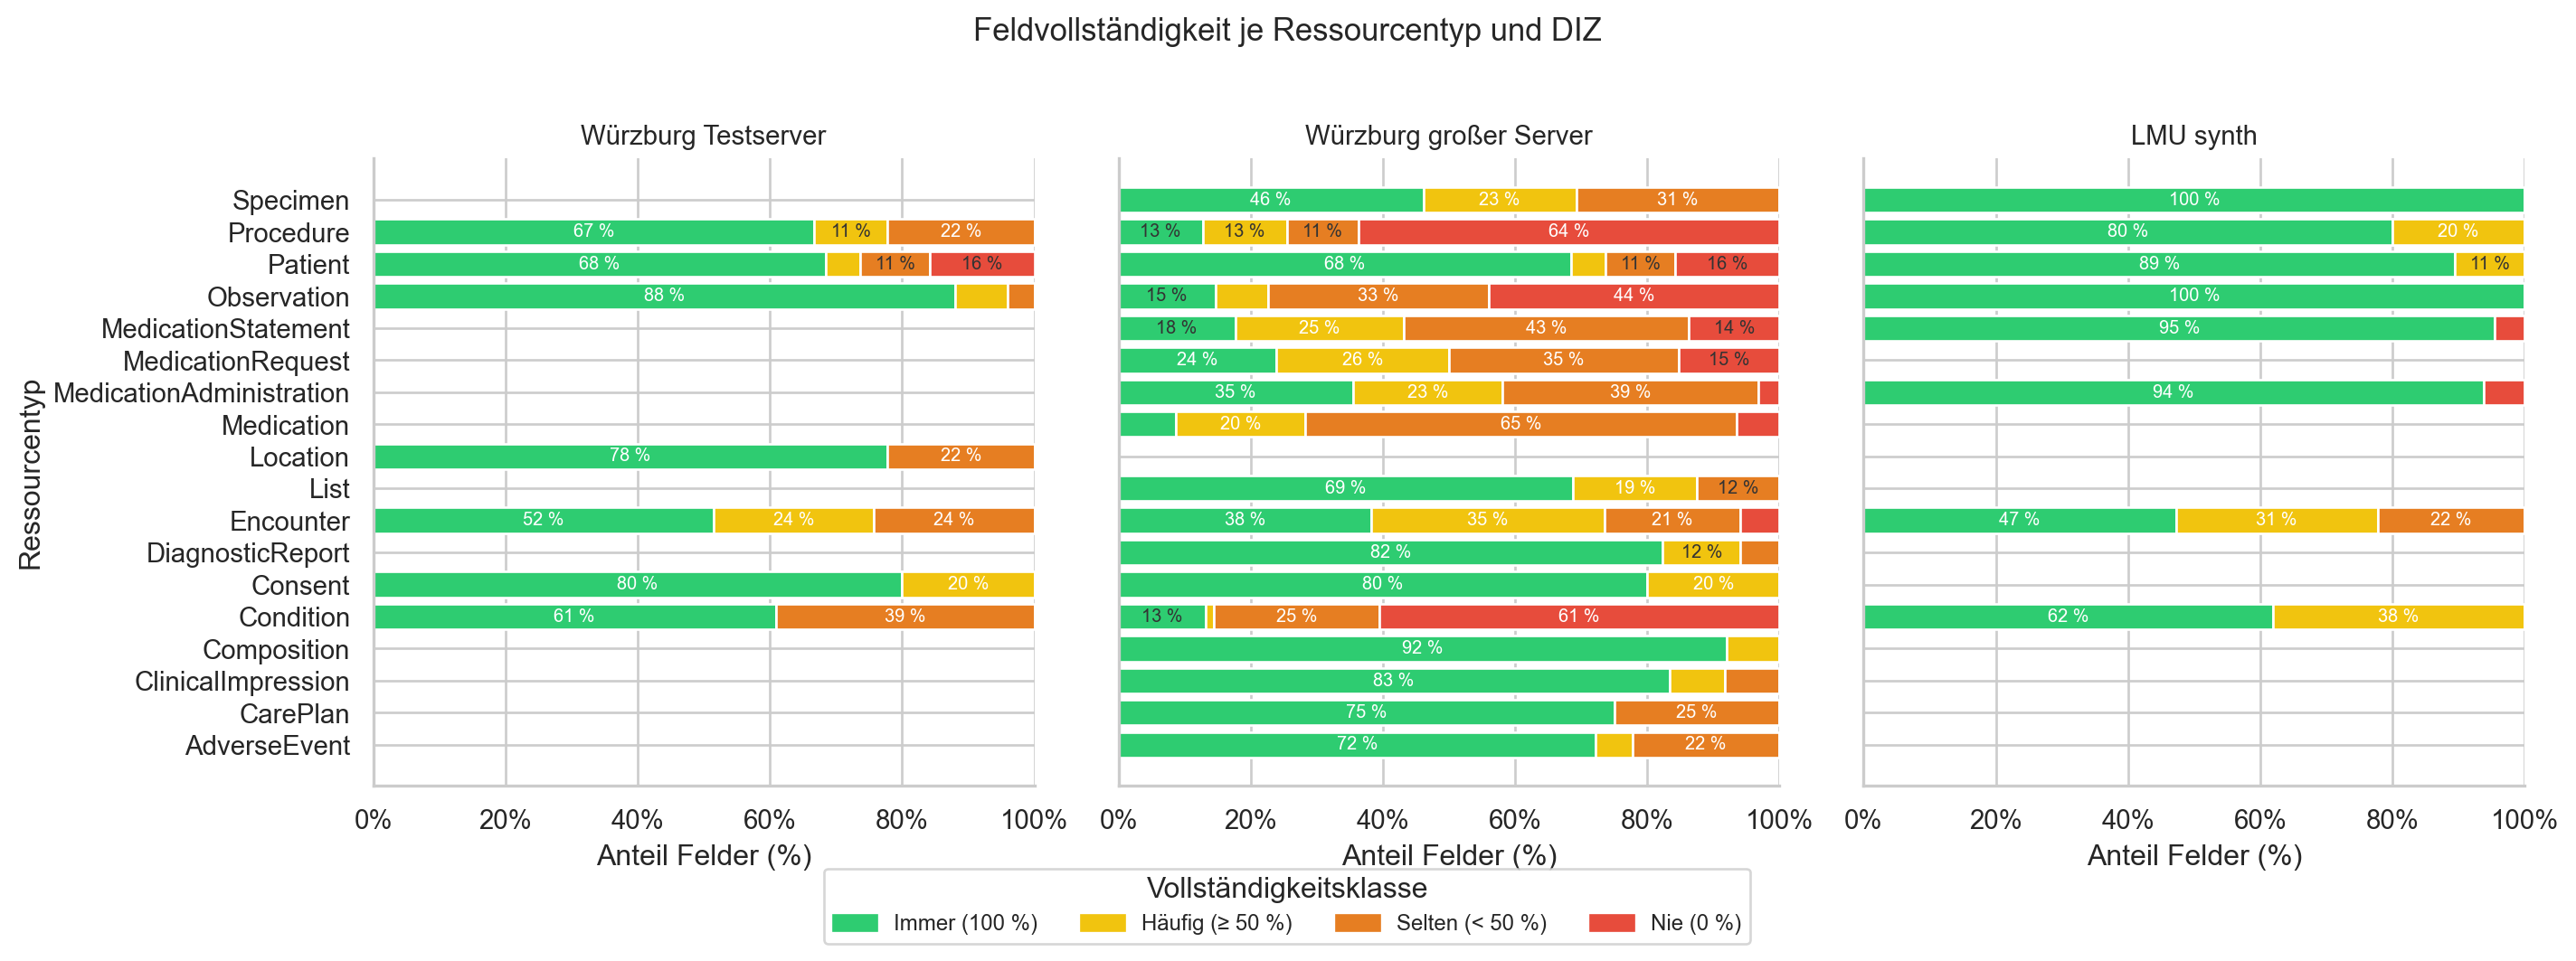

In [14]:
# ── 4c. Vollständigkeitsklassen je Ressourcentyp (gestapelte Balken) ───────
# Denominator = eigene Felder jedes DIZ. Felder anderer DIZ die diese DIZ
# nicht hat, zählen nicht (bleiben transparent wie in der Heatmap).
if not df_fields.empty:
    scalar_fields = df_fields[df_fields["_is_data_field"]].copy()

    classes   = ["Immer (100 %)", "Häufig (≥ 50 %)", "Selten (< 50 %)", "Nie (0 %)"]
    cls_colors = ["#2ecc71",       "#f1c40f",           "#e67e22",          "#e74c3c"]

    def classify_pr(r):
        if r == 1.0:  return "Immer (100 %)"
        if r >= 0.5:  return "Häufig (≥ 50 %)"
        if r > 0:     return "Selten (< 50 %)"
        return "Nie (0 %)"

    scalar_fields["cls"] = scalar_fields["presence_rate"].apply(classify_pr)

    n_diz = len(LOADED_DIZ)
    fig, axes = plt.subplots(1, n_diz, figsize=(max(8, n_diz * 5), 5), sharey=True)
    if n_diz == 1:
        axes = [axes]

    for ax, diz_name in zip(axes, LOADED_DIZ):
        sub = scalar_fields[scalar_fields["diz"] == diz_name]
        counts = (
            sub.groupby(["resource_type", "cls"])
            .size()
            .unstack(fill_value=0)
            .reindex(index=ALL_RT, columns=classes, fill_value=0)
        )
        pct = counts.div(counts.sum(axis=1).replace(0, 1), axis=0) * 100

        left = np.zeros(len(pct))
        for cls, color in zip(classes, cls_colors):
            vals = pct[cls].values if cls in pct else np.zeros(len(pct))
            bars = ax.barh(pct.index, vals, left=left, color=color,
                           label=cls if diz_name == LOADED_DIZ[0] else "")
            for bar, v, l in zip(bars, vals, left):
                if v > 9:
                    ax.text(l + v / 2, bar.get_y() + bar.get_height() / 2,
                            f"{v:.0f} %", ha="center", va="center",
                            fontsize=7.5, color="white" if v > 18 else "#333")
            left = left + vals

        ax.set_xlim(0, 100)
        ax.set_xlabel("Anteil Felder (%)")
        ax.set_title(diz_name, size=11)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter())
        sns.despine(ax=ax)

    axes[0].set_ylabel("Ressourcentyp")
    handles = [mpatches.Patch(color=c, label=l) for c, l in zip(cls_colors, classes)]
    fig.legend(handles=handles, loc="lower center", ncol=4,
               bbox_to_anchor=(0.5, -0.06), fontsize=9, title="Vollständigkeitsklasse")
    fig.suptitle("Feldvollständigkeit je Ressourcentyp und DIZ", size=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Keine Felddaten verfügbar.")


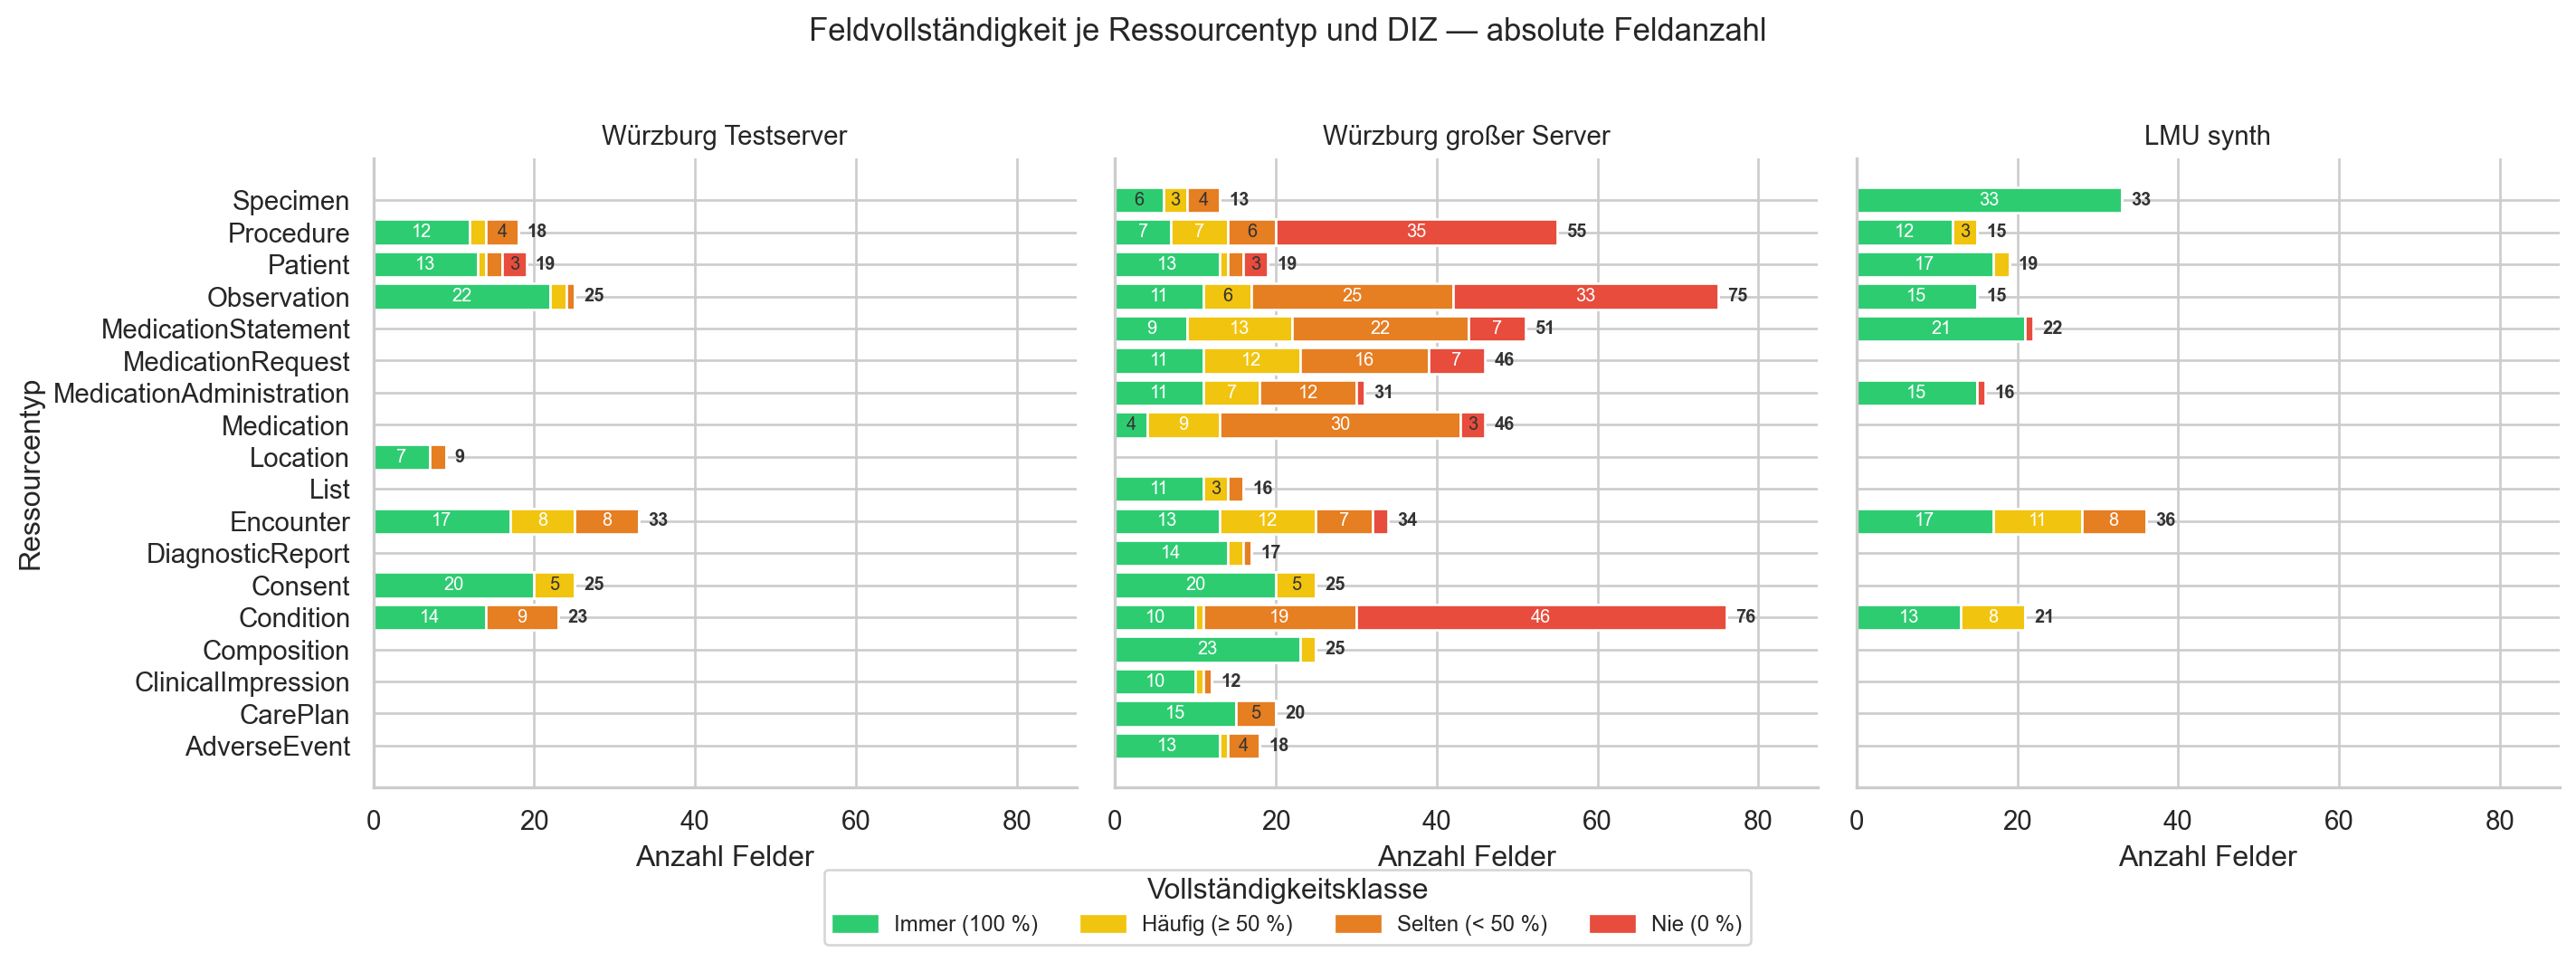

In [15]:
# ── 4c-abs. Feldvollständigkeit je Ressourcentyp — absolute Feldanzahl ────
# Gleiche Klassifikation wie 4c, aber als absolute Feldanzahl statt Prozent.
# Denominator = eigene Felder jedes DIZ (wie in 4c).
if not df_fields.empty:
    scalar_fields = df_fields[df_fields["_is_data_field"]].copy()

    classes    = ["Immer (100 %)", "Häufig (≥ 50 %)", "Selten (< 50 %)", "Nie (0 %)"]
    cls_colors = ["#2ecc71",       "#f1c40f",           "#e67e22",          "#e74c3c"]

    def classify_pr(r):
        if r == 1.0:  return "Immer (100 %)"
        if r >= 0.5:  return "Häufig (≥ 50 %)"
        if r > 0:     return "Selten (< 50 %)"
        return "Nie (0 %)"

    scalar_fields["cls"] = scalar_fields["presence_rate"].apply(classify_pr)

    def _counts_for(diz_name):
        sub = scalar_fields[scalar_fields["diz"] == diz_name]
        return (
            sub.groupby(["resource_type", "cls"])
            .size()
            .unstack(fill_value=0)
            .reindex(index=ALL_RT, columns=classes, fill_value=0)
        )

    n_diz = len(LOADED_DIZ)
    _max_count = max(_counts_for(d).sum(axis=1).max() for d in LOADED_DIZ)

    fig, axes = plt.subplots(1, n_diz, figsize=(max(8, n_diz * 5), 5), sharey=True, sharex=True)
    if n_diz == 1:
        axes = [axes]

    for ax, diz_name in zip(axes, LOADED_DIZ):
        counts = _counts_for(diz_name)

        left = np.zeros(len(counts))
        for cls, color in zip(classes, cls_colors):
            vals = counts[cls].values
            bars = ax.barh(counts.index, vals, left=left, color=color,
                           label=cls if diz_name == LOADED_DIZ[0] else "")
            for bar, v, l in zip(bars, vals, left):
                if v > max(1, _max_count * 0.03):
                    ax.text(l + v / 2, bar.get_y() + bar.get_height() / 2,
                            f"{int(v)}", ha="center", va="center",
                            fontsize=7.5, color="white" if v > _max_count * 0.08 else "#333")
            left = left + vals

        totals = counts.sum(axis=1).values
        for i, total in enumerate(totals):
            if total > 0:
                ax.text(total + _max_count * 0.015, i, f"{int(total)}",
                        ha="left", va="center", fontsize=7.5,
                        color="#333", fontweight="bold")

        ax.set_xlim(0, _max_count * 1.15)
        ax.set_xlabel("Anzahl Felder")
        ax.set_title(diz_name, size=11)
        sns.despine(ax=ax)

    axes[0].set_ylabel("Ressourcentyp")
    handles = [mpatches.Patch(color=c, label=l) for c, l in zip(cls_colors, classes)]
    fig.legend(handles=handles, loc="lower center", ncol=4,
               bbox_to_anchor=(0.5, -0.06), fontsize=9, title="Vollständigkeitsklasse")
    fig.suptitle("Feldvollständigkeit je Ressourcentyp und DIZ — absolute Feldanzahl", size=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Keine Felddaten verfügbar.")


### 4d. Feldvollständigkeit — Vergleichsansicht (gleicher Nenner)

Union aller DIZ als Felduniversum. Rot = Feld im CSV vorhanden aber nie befüllt (presence = 0). Grau (N/A) = Feld taucht in diesem Profiling-Lauf gar nicht auf. Quelle: `*_fields.csv` → `presence_rate`.

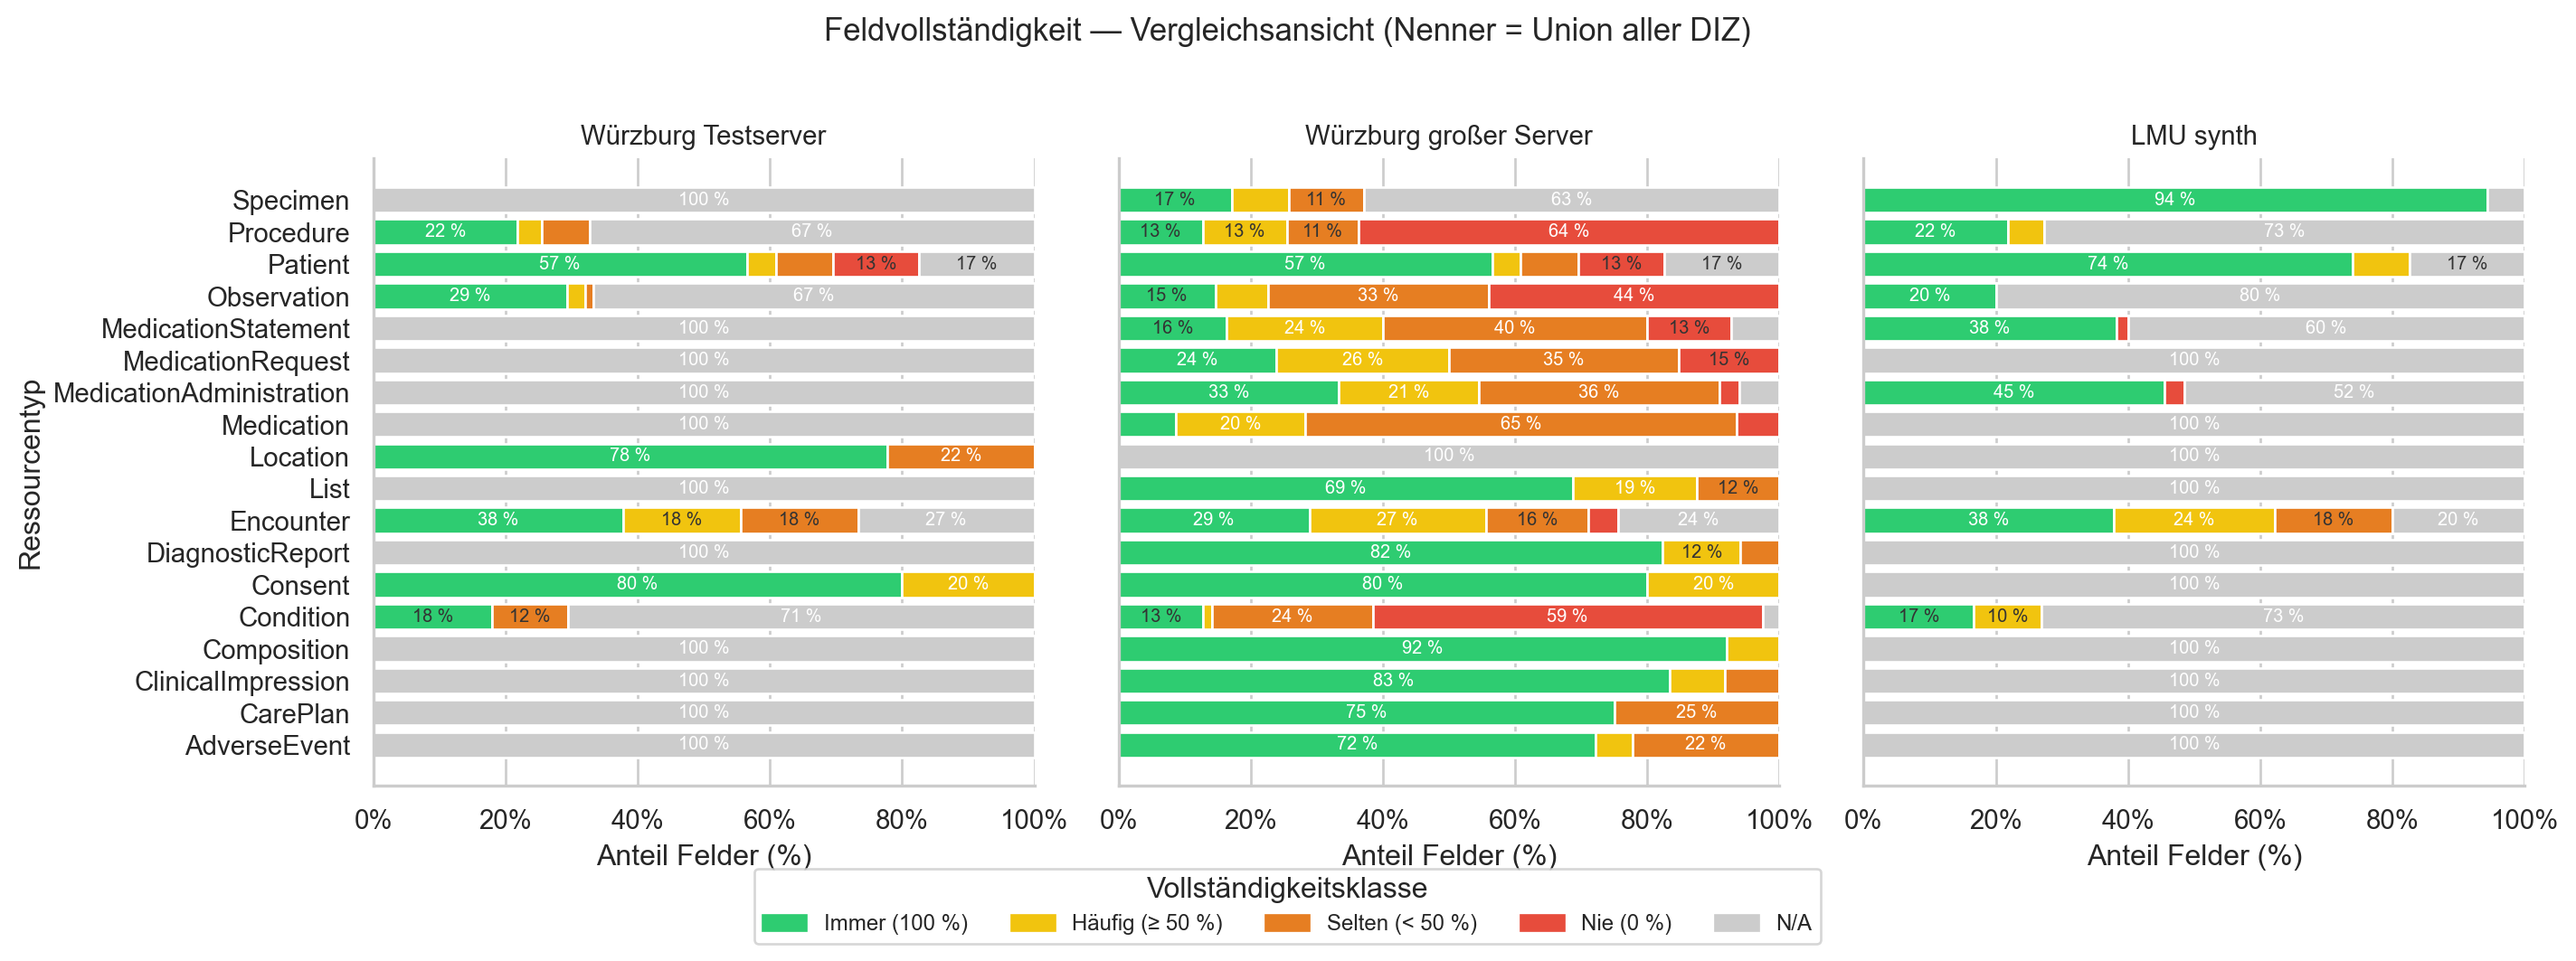

In [16]:
# ── 4d. Feldvollständigkeit — Vergleichsansicht (gleicher Nenner) ──────────
# Union aller DIZ als Felduniversum. NaN (= Feld nicht im Profiling-Lauf)
# erscheint als eigene graue Kategorie — getrennt von Nie (0 %).
if not df_fields.empty:
    classes_cmp    = ["Immer (100 %)", "Häufig (≥ 50 %)", "Selten (< 50 %)", "Nie (0 %)", "N/A"]
    cls_colors_cmp = ["#2ecc71",       "#f1c40f",           "#e67e22",          "#e74c3c",   "#cccccc"]

    def _cls_cmp(r):
        if r is None:   return "N/A"
        if r == 1.0:    return "Immer (100 %)"
        if r >= 0.5:    return "Häufig (≥ 50 %)"
        if r > 0:       return "Selten (< 50 %)"
        return "Nie (0 %)"

    _scalar_cmp = df_fields[df_fields["_is_data_field"]].copy()

    # Union-Pivot — NaN bleibt NaN (nicht fillna!)
    _upv_cmp = (
        _scalar_cmp
        .pivot_table(index=["resource_type", "field_path"], columns="diz",
                     values="presence_rate", aggfunc="first")
        .reindex(columns=LOADED_DIZ)
        .reset_index()
    )

    # Melt: NaN explizit als None übergeben
    _melted_cmp = _upv_cmp.melt(
        id_vars=["resource_type", "field_path"],
        value_vars=LOADED_DIZ, var_name="diz", value_name="presence_rate"
    )
    _melted_cmp["cls"] = _melted_cmp["presence_rate"].apply(
        lambda x: _cls_cmp(None if pd.isna(x) else x)
    )

    counts_cmp = (
        _melted_cmp.groupby(["diz", "resource_type", "cls"])
        .size()
        .unstack("cls", fill_value=0)
        .reindex(columns=classes_cmp, fill_value=0)
        .reset_index()
    )
    counts_cmp["total"] = counts_cmp[classes_cmp].sum(axis=1)

    n_diz = len(LOADED_DIZ)
    fig, axes = plt.subplots(1, n_diz, figsize=(max(8, n_diz * 5), 5), sharey=True)
    if n_diz == 1:
        axes = [axes]

    for ax, diz_name in zip(axes, LOADED_DIZ):
        sub = counts_cmp[counts_cmp["diz"] == diz_name].copy()
        pct = sub[classes_cmp].div(sub["total"].replace(0, 1).values, axis=0) * 100

        left = np.zeros(len(sub))
        for cls, color in zip(classes_cmp, cls_colors_cmp):
            vals = pct[cls].values
            bars = ax.barh(sub["resource_type"].tolist(), vals, left=left,
                           color=color, label=cls if diz_name == LOADED_DIZ[0] else "")
            for bar, v, l in zip(bars, vals, left):
                if v > 9:
                    ax.text(l + v / 2, bar.get_y() + bar.get_height() / 2,
                            f"{v:.0f} %", ha="center", va="center",
                            fontsize=7.5, color="white" if v > 18 else "#333")
            left = left + vals

        ax.set_xlim(0, 100)
        ax.set_xlabel("Anteil Felder (%)")
        ax.set_title(diz_name, size=11)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter())
        sns.despine(ax=ax)

    axes[0].set_ylabel("Ressourcentyp")
    handles = [mpatches.Patch(color=c, label=l)
               for c, l in zip(cls_colors_cmp, classes_cmp)]
    fig.legend(handles=handles, loc="lower center", ncol=5,
               bbox_to_anchor=(0.5, -0.06), fontsize=9, title="Vollständigkeitsklasse")
    fig.suptitle("Feldvollständigkeit — Vergleichsansicht (Nenner = Union aller DIZ)",
                 size=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Keine Felddaten verfügbar.")


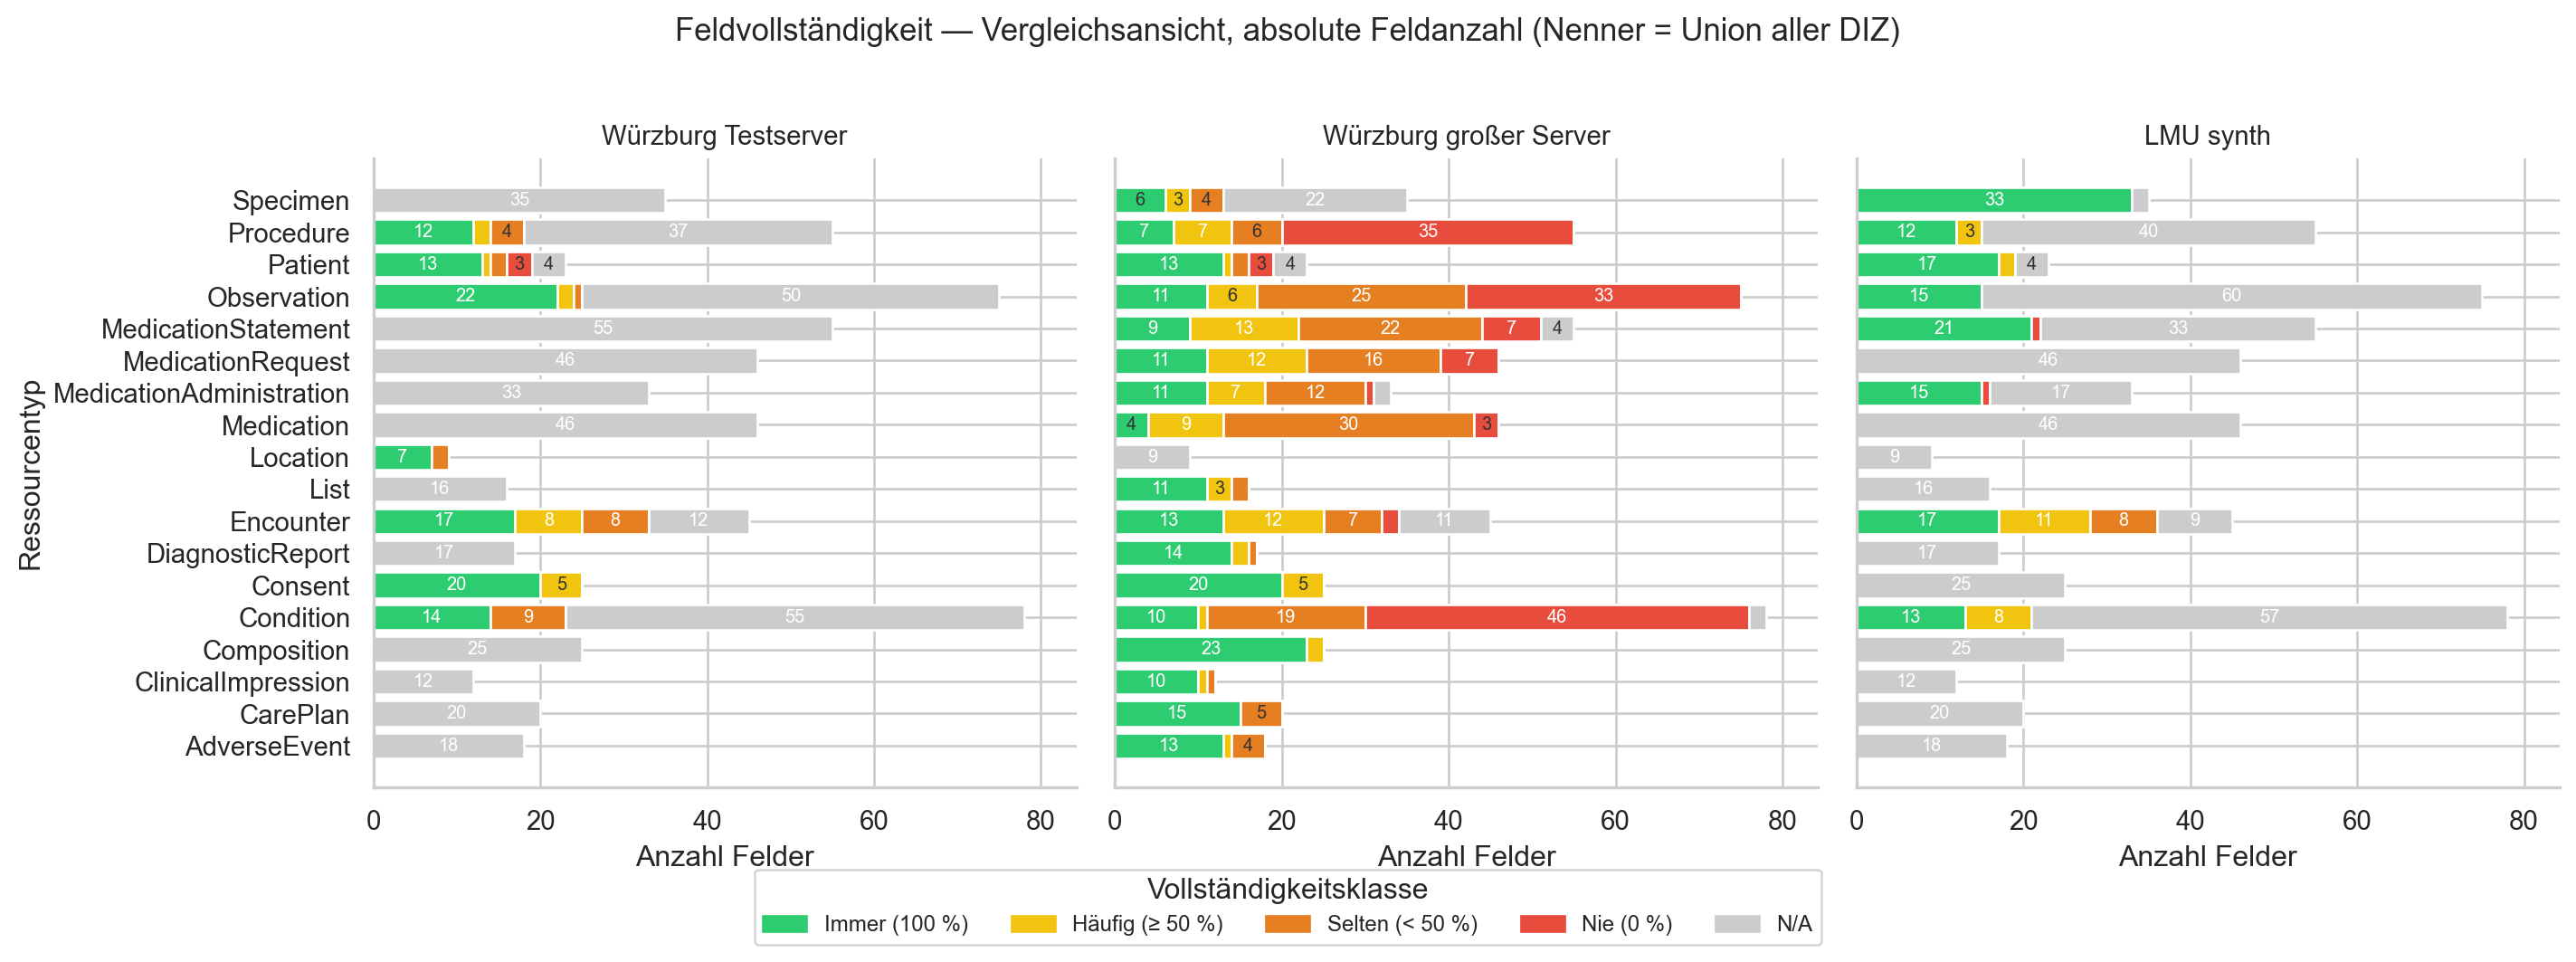

In [17]:
# ── 4d-abs. Feldvollständigkeit — Vergleichsansicht, absolute Feldanzahl ──
# Union aller DIZ als Felduniversum (wie in 4d), absolute Feldanzahl statt Prozent.
if not df_fields.empty:
    classes_cmp    = ["Immer (100 %)", "Häufig (≥ 50 %)", "Selten (< 50 %)", "Nie (0 %)", "N/A"]
    cls_colors_cmp = ["#2ecc71",       "#f1c40f",           "#e67e22",          "#e74c3c",   "#cccccc"]

    def _cls_cmp(r):
        if r is None:   return "N/A"
        if r == 1.0:    return "Immer (100 %)"
        if r >= 0.5:    return "Häufig (≥ 50 %)"
        if r > 0:       return "Selten (< 50 %)"
        return "Nie (0 %)"

    _scalar_cmp = df_fields[df_fields["_is_data_field"]].copy()

    _upv_cmp = (
        _scalar_cmp
        .pivot_table(index=["resource_type", "field_path"], columns="diz",
                     values="presence_rate", aggfunc="first")
        .reindex(columns=LOADED_DIZ)
        .reset_index()
    )
    _melted_cmp = _upv_cmp.melt(
        id_vars=["resource_type", "field_path"],
        value_vars=LOADED_DIZ, var_name="diz", value_name="presence_rate"
    )
    _melted_cmp["cls"] = _melted_cmp["presence_rate"].apply(
        lambda x: _cls_cmp(None if pd.isna(x) else x)
    )

    counts_cmp = (
        _melted_cmp.groupby(["diz", "resource_type", "cls"])
        .size()
        .unstack("cls", fill_value=0)
        .reindex(columns=classes_cmp, fill_value=0)
        .reset_index()
    )

    n_diz = len(LOADED_DIZ)
    _max_count = counts_cmp[classes_cmp].sum(axis=1).max()

    fig, axes = plt.subplots(1, n_diz, figsize=(max(8, n_diz * 5), 5), sharey=True, sharex=True)
    if n_diz == 1:
        axes = [axes]

    for ax, diz_name in zip(axes, LOADED_DIZ):
        sub = (
            counts_cmp[counts_cmp["diz"] == diz_name]
            .set_index("resource_type")
            .reindex(ALL_RT, fill_value=0)
        )

        left = np.zeros(len(sub))
        for cls, color in zip(classes_cmp, cls_colors_cmp):
            vals = sub[cls].values
            bars = ax.barh(sub.index, vals, left=left,
                           color=color, label=cls if diz_name == LOADED_DIZ[0] else "")
            for bar, v, l in zip(bars, vals, left):
                if v > max(1, _max_count * 0.03):
                    ax.text(l + v / 2, bar.get_y() + bar.get_height() / 2,
                            f"{int(v)}", ha="center", va="center",
                            fontsize=7.5, color="white" if v > _max_count * 0.08 else "#333")
            left = left + vals

        ax.set_xlim(0, _max_count * 1.08)
        ax.set_xlabel("Anzahl Felder")
        ax.set_title(diz_name, size=11)
        sns.despine(ax=ax)

    axes[0].set_ylabel("Ressourcentyp")
    handles = [mpatches.Patch(color=c, label=l)
               for c, l in zip(cls_colors_cmp, classes_cmp)]
    fig.legend(handles=handles, loc="lower center", ncol=5,
               bbox_to_anchor=(0.5, -0.06), fontsize=9, title="Vollständigkeitsklasse")
    fig.suptitle("Feldvollständigkeit — Vergleichsansicht, absolute Feldanzahl (Nenner = Union aller DIZ)",
                 size=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Keine Felddaten verfügbar.")


***
## 5. Größte Abweichungen zwischen DIZ

Felder mit der größten Spannweite (Max − Min `presence_rate`) zwischen allen DIZ. Nur Felder mit max presence > 1 %. Quelle: `*_fields.csv` → `presence_rate`.

In [18]:
# Parameter anpassen:
TOP_N_FIELDS = 25   # Wie viele Felder je Ressourcentyp anzeigen
MIN_PRESENCE = 0.01  # Felder ignorieren die überall < 1% vorhanden sind

if not df_fields.empty and len(LOADED_DIZ) > 1:
    scalar_fields = df_fields[
        df_fields["_is_data_field"]
    ].copy()

    results = []
    for rt in ALL_RT:
        sub = scalar_fields[scalar_fields["resource_type"] == rt]
        pivot = sub.pivot_table(
            index="field_path", columns="diz",
            values="presence_rate", aggfunc="first"
        ).reindex(columns=LOADED_DIZ)

        pivot = pivot[pivot.max(axis=1) > MIN_PRESENCE]
        if pivot.empty:
            continue

        pivot["std"] = pivot[LOADED_DIZ].std(axis=1)
        pivot["range"] = pivot[LOADED_DIZ].max(axis=1) - pivot[LOADED_DIZ].min(axis=1)
        pivot["mean"] = pivot[LOADED_DIZ].mean(axis=1)
        pivot["resource_type"] = rt
        pivot = pivot.reset_index()
        results.append(pivot)

    if results:
        df_divergence = pd.concat(results, ignore_index=True)
        df_divergence = df_divergence.sort_values("range", ascending=False)

        # ── Top-N global ──────────────────────────────────────────────────
        top_global = df_divergence.head(TOP_N_FIELDS)

        fig = px.bar(
            top_global,
            x="range", y="field_path",
            color="resource_type",
            orientation="h",
            title=f"Top {TOP_N_FIELDS} Felder mit größter Presence-Rate-Spannweite zwischen DIZ",
            labels={"range": "Max − Min Presence Rate", "field_path": "Feldpfad"},
            height=max(500, TOP_N_FIELDS * 26 + 120)
        )
        fig.update_layout(yaxis=dict(autorange="reversed"))
        fig.show()

        # ── Top-N pro Ressourcentyp ───────────────────────────────────────
        print("\nTop-Abweichungen je Ressourcentyp:")
        display_cols = ["resource_type", "field_path", "mean", "std", "range"] + LOADED_DIZ
        available = [c for c in display_cols if c in df_divergence.columns]
        display(
            df_divergence.groupby("resource_type")
            .head(5)[available]
            .sort_values(["resource_type", "range"], ascending=[True, False])
            .reset_index(drop=True)
            .style.format({c: "{:.3f}" for c in ["mean", "std", "range"] + LOADED_DIZ if c in df_divergence.columns})
            .background_gradient(subset=["range"], cmap="YlOrRd")
        )
else:
    print("Mindestens 2 DIZ erforderlich für Divergenzanalyse.")


Top-Abweichungen je Ressourcentyp:


diz,resource_type,field_path,mean,std,range,Würzburg Testserver,Würzburg großer Server,LMU synth
0,AdverseEvent,AdverseEvent.actuality,1.000,nan,0.000,nan,1.000,nan
1,AdverseEvent,AdverseEvent.suspectEntity[].instance.reference,1.000,nan,0.000,nan,1.000,nan
2,AdverseEvent,AdverseEvent.subject.reference,1.000,nan,0.000,nan,1.000,nan
3,AdverseEvent,AdverseEvent.seriousness.coding[].system,1.000,nan,0.000,nan,1.000,nan
4,AdverseEvent,AdverseEvent.seriousness.coding[].code,1.000,nan,0.000,nan,1.000,nan
5,CarePlan,CarePlan.identifier[].value,1.000,nan,0.000,nan,1.000,nan
6,CarePlan,CarePlan.identifier[].system,1.000,nan,0.000,nan,1.000,nan
7,CarePlan,CarePlan.id,1.000,nan,0.000,nan,1.000,nan
8,CarePlan,CarePlan.created,1.000,nan,0.000,nan,1.000,nan
9,CarePlan,CarePlan.category[].coding[].system,1.000,nan,0.000,nan,1.000,nan


***
## 6. Wertverteilung für kodierte Felder

Verteilung der häufigsten Werte je DIZ, normiert auf den Anteil aller Feldwerte. Quelle: `*_fields.csv` → `top_values` (JSON-Liste der häufigsten Werte und ihre Anzahl).

In [19]:
# ── Parameter: Felder für die Wertverteilung anzeigen ─────────────────────
# Kommentiere Felder aus die in deinen Daten nicht vorhanden sind.
VALUE_FIELDS_OF_INTEREST = [
    # Passe diese Liste an deine tatsächlichen Feldpfade an:
    "Observation.code.coding[].code",
    "Condition.code.coding[].code",
    "Encounter.class.code",          # R4: Encounter.class ist Coding, nicht CodeableConcept
    "Observation.status",
    "Condition.clinicalStatus.coding[].code",
    "Procedure.status",
]
TOP_VALUES_SHOW = 15   # Wie viele Werte pro Feld anzeigen

# ─────────────────────────────────────────────────────────────────────────
def plot_value_distribution(field_path: str):
    sub = df_fields[df_fields["field_path"] == field_path]
    if sub.empty:
        print(f"Feld '{field_path}' nicht in den Daten gefunden.")
        return

    all_diz_data = []
    for _, row in sub.iterrows():
        tv = parse_top_values(row.get("top_values", ""))
        for value, count in list(tv.items())[:TOP_VALUES_SHOW]:
            all_diz_data.append({
                "diz": row["diz"],
                "value": value,
                "count": count,
                "total": row.get("value_count", 1)
            })

    if not all_diz_data:
        print(f"Keine top_values Daten für '{field_path}'.")
        return

    df_tv = pd.DataFrame(all_diz_data)
    df_tv["rate"] = df_tv["count"] / df_tv["total"]

    # Top-Werte global (nach Gesamtvorkommen sortieren)
    top_values_global = (
        df_tv.groupby("value")["count"].sum()
        .sort_values(ascending=False)
        .head(TOP_VALUES_SHOW)
        .index.tolist()
    )
    df_tv = df_tv[df_tv["value"].isin(top_values_global)]

    fig = px.bar(
        df_tv,
        x="value", y="rate", color="diz",
        barmode="group",
        color_discrete_map=COLOR_MAP,
        title=f"Wertverteilung: {field_path}",
        labels={"rate": "Anteil an Feldwerten", "value": "Wert", "diz": "DIZ"},
        height=420
    )
    fig.update_yaxes(tickformat=".1%")
    fig.update_xaxes(tickangle=-30)
    fig.show()


for field_path in VALUE_FIELDS_OF_INTEREST:
    plot_value_distribution(field_path)

In [20]:
# ── 6b. Automatisch die Felder mit den meisten distinkt-Werten finden ─────
# (als Ausgangspunkt für manuelle Auswahl oben)

if not df_fields.empty:
    coded_candidates = df_fields[
        (df_fields["detected_fhir_type"].isin(["code", "CodeableConcept", "Coding", "uri"])) &
        (df_fields["presence_rate"] > 0.5) &
        (df_fields["_is_data_field"]) &
        (df_fields["unique_count"] > 1) &
        (df_fields["unique_count"] < 500)   # Zu viele Werte = keine sinnvolle Verteilung
    ].copy()

    if not coded_candidates.empty:
        print("Vorschläge für VALUE_FIELDS_OF_INTEREST (oft vorhandene kodierte Felder):")
        display(
            coded_candidates
            .groupby(["resource_type", "field_path"])["unique_count"]
            .mean()
            .sort_values(ascending=False)
            .head(20)
            .reset_index()
            .rename(columns={"unique_count": "Ø unique_count"})
        )

Vorschläge für VALUE_FIELDS_OF_INTEREST (oft vorhandene kodierte Felder):


,resource_type,field_path,Ø unique_count
0,Consent,Consent.patient.reference,276.000
1,Consent,Consent.identifier[].value,276.000
2,Observation,Observation.code.text,247.000
3,Observation,Observation.code.coding[].code,194.667
4,Patient,Patient.address[].country,128.000
5,MedicationStatement,MedicationStatement.informationSource.reference,111.000
6,Patient,Patient.address[].postalCode,100.000
7,Observation,Observation.valueQuantity.code,42.000
8,Observation,Observation.valueQuantity.unit,41.500
9,MedicationRequest,MedicationRequest.dosageInstruction[].site.coding[].code,38.000


***
## 7. Kardinalitäts-Boxplots

Box = P25–P75, Mittelstrich = Median, Whisker = Min/P99, Dreieck = Mittelwert. Quelle: `03_cardinality.csv` → Perzentil-Spalten.

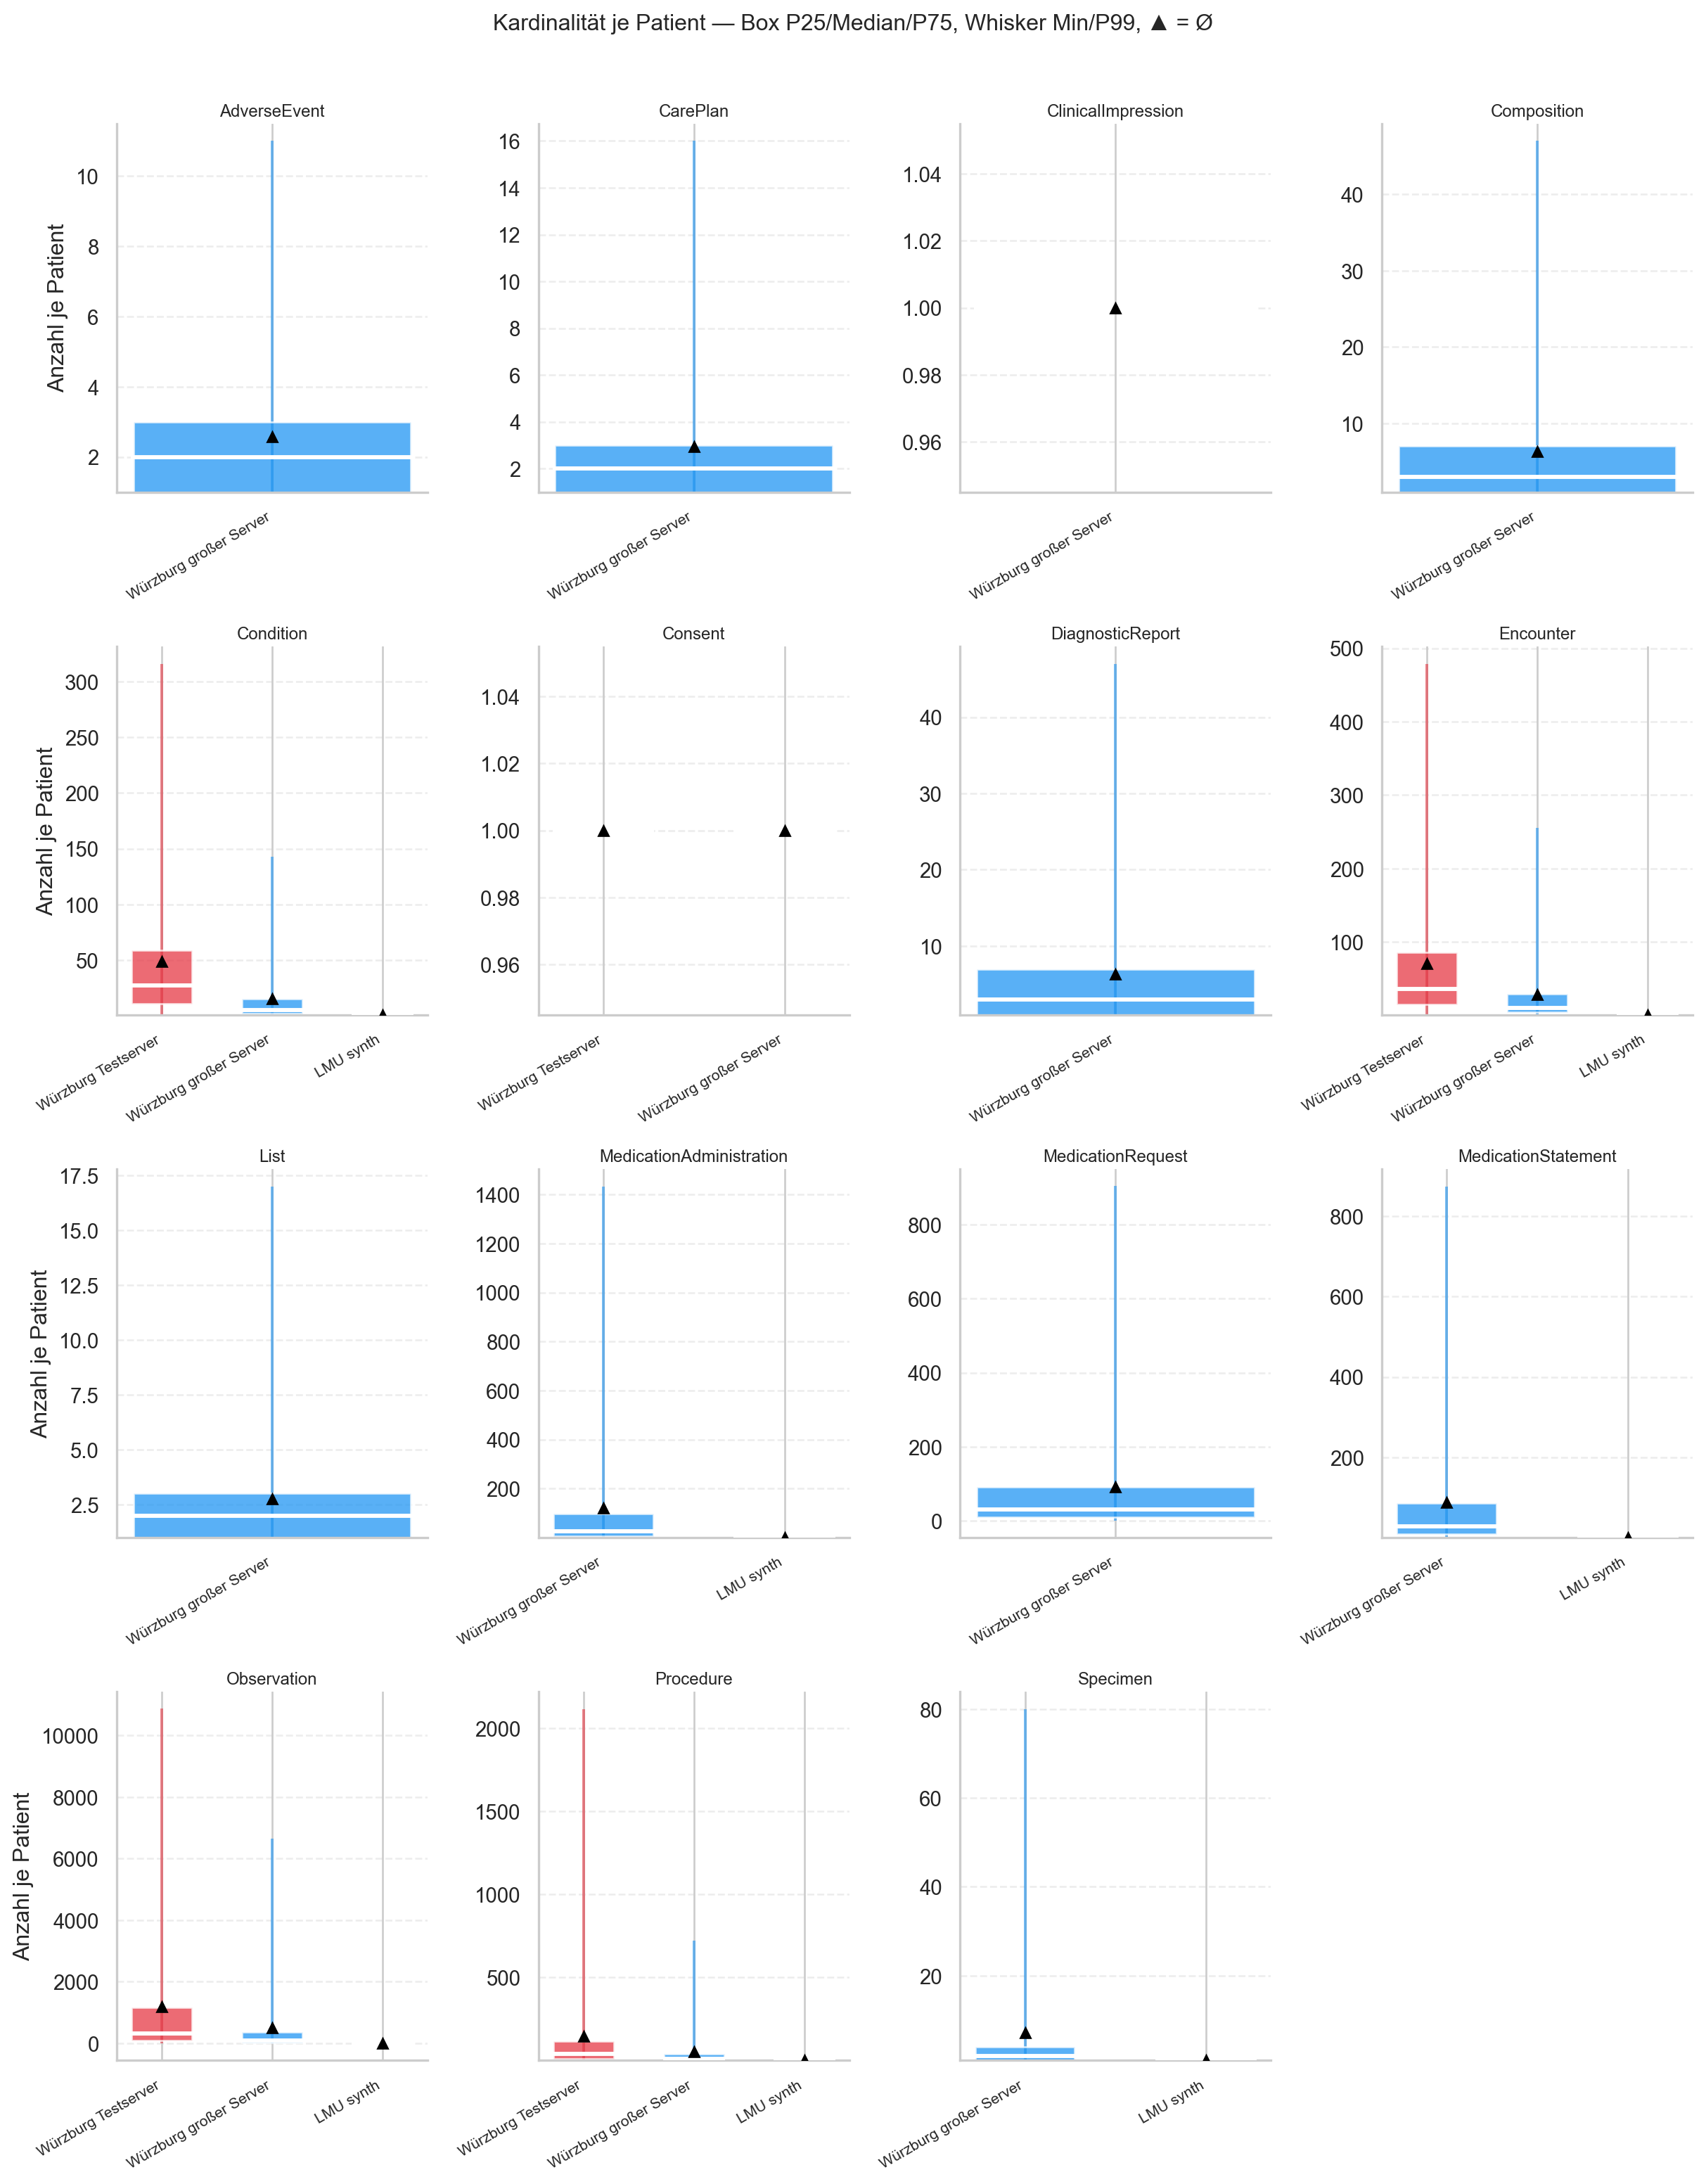

In [21]:
# ── 7. Kardinalitäts-Boxplots (per_patient, aus Perzentil-Daten) ──────────
if not df_card.empty and {"median", "p25", "p75", "min", "p99"}.issubset(df_card.columns):
    sub = df_card[
        (df_card["anchor_type"] == "per_patient") &
        (df_card["coverage_rate"] > 0)
    ].copy()

    resource_types = sorted(sub["resource_type"].unique())
    ncols = min(4, len(resource_types))
    nrows = (len(resource_types) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 3.2, nrows * 4),
                             squeeze=False)

    for idx, rt in enumerate(resource_types):
        ax = axes[idx // ncols][idx % ncols]
        rt_data = sub[sub["resource_type"] == rt].reset_index(drop=True)

        for i, row in rt_data.iterrows():
            diz = row["diz"]
            color = MPL_COLOR_MAP.get(diz, "steelblue")
            p25, med, p75 = row["p25"], row["median"], row["p75"]
            wlo, whi = row["min"], row["p99"]

            ax.vlines(i, wlo, whi, color=color, linewidth=1.5, zorder=1, alpha=0.6)
            ax.bar(i, p75 - p25, bottom=p25, width=0.55,
                   color=color, alpha=0.75, zorder=2)
            ax.hlines(med, i - 0.28, i + 0.28, color="white", linewidth=2.2, zorder=3)
            if "mean" in row and not pd.isna(row["mean"]):
                ax.plot(i, row["mean"], "^", color="black", ms=5, zorder=4)

        ax.set_xticks(range(len(rt_data)))
        ax.set_xticklabels(rt_data["diz"].tolist(), rotation=30, ha="right", size=8)
        ax.set_title(rt, size=9, pad=4)
        ax.set_ylabel("Anzahl je Patient" if idx % ncols == 0 else "")
        ax.grid(axis="y", alpha=0.35, linestyle="--")
        sns.despine(ax=ax)

    # Leere Achsen ausblenden
    for idx in range(len(resource_types), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle("Kardinalität je Patient — Box P25/Median/P75, Whisker Min/P99, ▲ = Ø",
                 size=12, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Kardinalitätsdaten fehlen oder unvollständig.")

***
## 8. DIZ-Korrelationsanalyse

### 8a. Korrelations-Heatmap

Pearson-Korrelation der `presence_rate`-Vektoren zwischen DIZ-Paaren. Werte nahe 1.0 = ähnliche Befüllungsstruktur. Quelle: `*_fields.csv` → `presence_rate` aller Datenfelder.

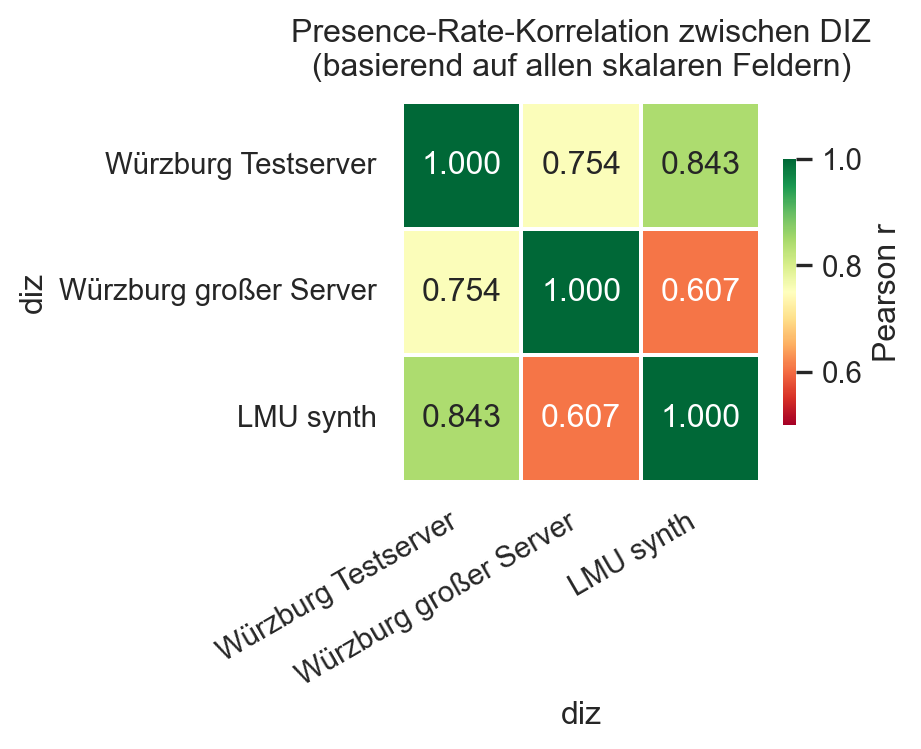

In [22]:
# ── 8a. Korrelations-Heatmap zwischen DIZ ───────────────────────────────
if not df_fields.empty and len(LOADED_DIZ) >= 2:
    scalar_fields = df_fields[
        df_fields["_is_data_field"]
    ].copy()

    pivot_corr = scalar_fields.pivot_table(
        index=["resource_type", "field_path"], columns="diz",
        values="presence_rate", aggfunc="first"
    ).reindex(columns=LOADED_DIZ)

    corr = pivot_corr.corr()
    size = max(4, len(LOADED_DIZ) * 1.6)

    fig, ax = plt.subplots(figsize=(size, size * 0.85))
    mask = np.zeros_like(corr, dtype=bool)
    np.fill_diagonal(mask, False)

    sns.heatmap(
        corr, annot=True, fmt=".3f", cmap="RdYlGn",
        vmin=0.5, vmax=1.0, linewidths=0.8,
        annot_kws={"size": 12},
        ax=ax, cbar_kws={"label": "Pearson r", "shrink": 0.7}
    )
    ax.set_title("Presence-Rate-Korrelation zwischen DIZ\n(basierend auf allen skalaren Feldern)",
                 size=12, pad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()
elif len(LOADED_DIZ) < 2:
    print("Mindestens 2 DIZ für Korrelationsanalyse erforderlich.")
else:
    print("Keine Felddaten verfügbar.")

### 8b. Scatter: Presence Rate DIZ-Paare

Jeder Punkt = ein Feld, x/y = `presence_rate` im jeweiligen DIZ. Punkte auf der Diagonalen = identische Rate; darüber/darunter = ein DIZ befüllt häufiger. Quelle: `*_fields.csv` → `presence_rate`.

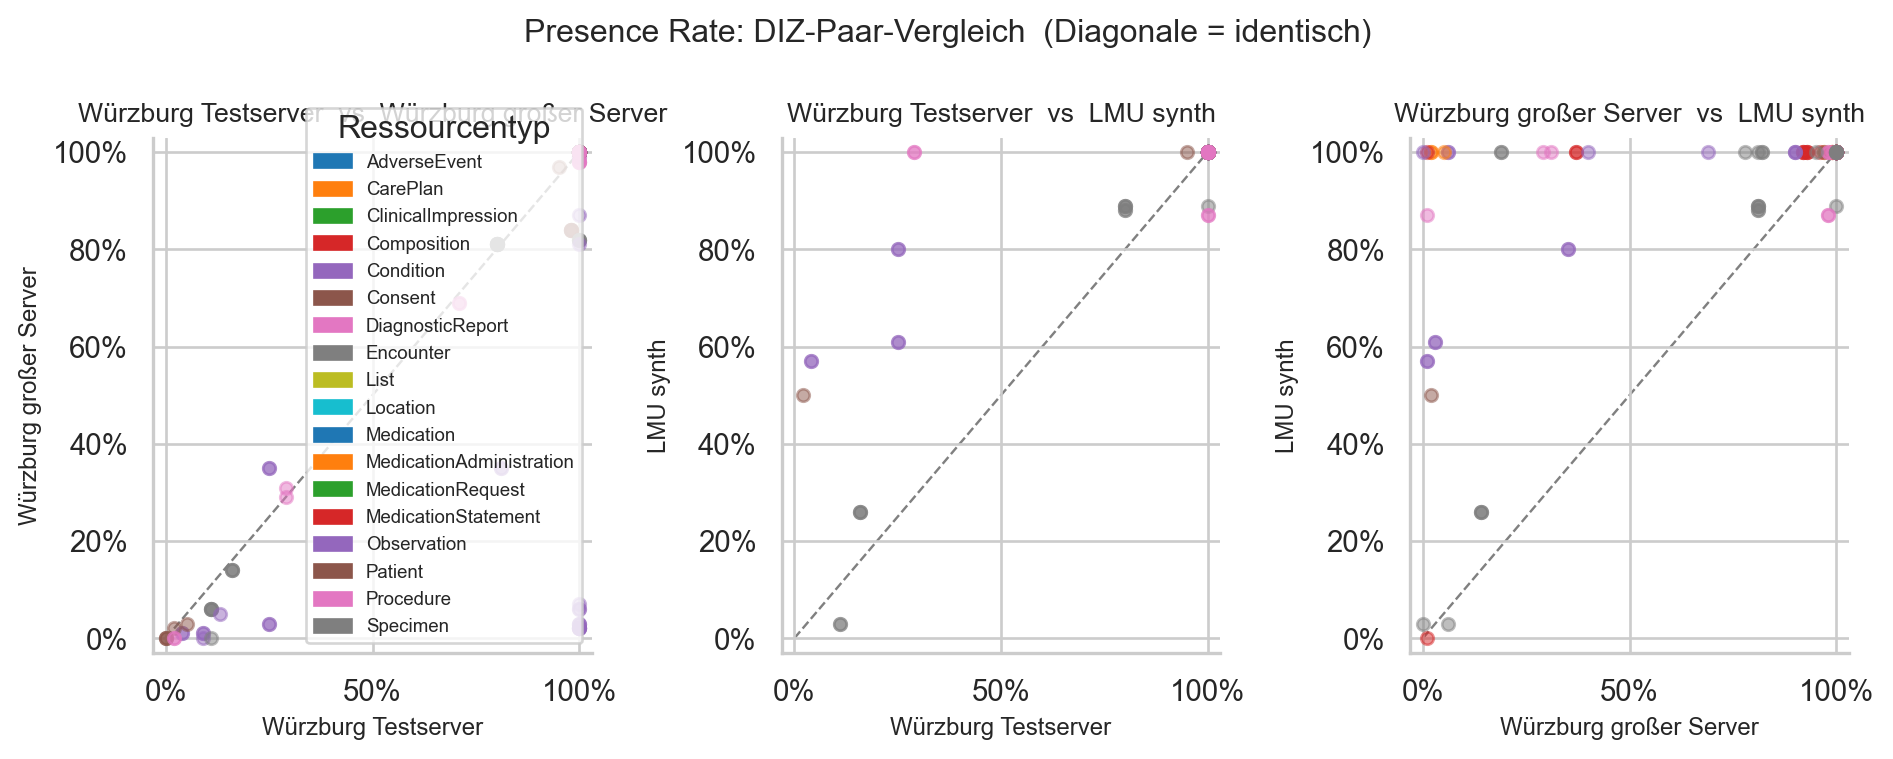

In [23]:
# ── 8b. Scatter: Presence Rate DIZ-Paar-Vergleich ───────────────────────
if not df_fields.empty and len(LOADED_DIZ) >= 2:
    scalar_fields = df_fields[
        df_fields["_is_data_field"]
    ].copy()

    pivot_sc = scalar_fields.pivot_table(
        index=["resource_type", "field_path"], columns="diz",
        values="presence_rate", aggfunc="first"
    ).reindex(columns=LOADED_DIZ).reset_index()

    pairs = [(LOADED_DIZ[i], LOADED_DIZ[j])
             for i in range(len(LOADED_DIZ))
             for j in range(i + 1, len(LOADED_DIZ))]

    rt_palette = dict(zip(ALL_RT, sns.color_palette("tab10", len(ALL_RT))))

    ncols = min(3, len(pairs))
    nrows = (len(pairs) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(min(ncols * 4.2, 10), nrows * 4.0),
                             squeeze=False)

    for idx, (diz_a, diz_b) in enumerate(pairs):
        ax = axes[idx // ncols][idx % ncols]
        for rt in ALL_RT:
            sub = pivot_sc[pivot_sc["resource_type"] == rt]
            if diz_a not in sub.columns or diz_b not in sub.columns:
                continue
            valid = sub[[diz_a, diz_b]].dropna()
            ax.scatter(valid[diz_a], valid[diz_b],
                       color=rt_palette.get(rt, "grey"),
                       alpha=0.5, s=22, label=rt, zorder=2)

        ax.plot([0, 1], [0, 1], "--", color="grey", lw=0.9, zorder=0)
        ax.set_xlim(-0.03, 1.03)
        ax.set_ylim(-0.03, 1.03)
        ax.set_xlabel(diz_a, size=9)
        ax.set_ylabel(diz_b, size=9)
        ax.set_title(f"{diz_a}  vs  {diz_b}", size=10)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        sns.despine(ax=ax)

    # Ressourcentyp-Legende in das erste Subplot
    handles = [mpatches.Patch(color=rt_palette.get(rt, "grey"), label=rt) for rt in ALL_RT]
    axes[0][0].legend(handles=handles, loc="lower right", fontsize=7, title="Ressourcentyp")

    # Leere Achsen ausblenden
    for idx in range(len(pairs), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle("Presence Rate: DIZ-Paar-Vergleich  (Diagonale = identisch)", size=12)
    plt.tight_layout()
    plt.show()
elif len(LOADED_DIZ) < 2:
    print("Mindestens 2 DIZ für Paar-Scatter erforderlich.")
else:
    print("Keine Felddaten verfügbar.")

***
## 9. Typ-Inkonsistenzen

Felder mit inkonsistenten Python-Typen (z. B. mal string, mal int) je Ressourcentyp. Quelle: `*_fields.csv` → `type_inconsistency`.

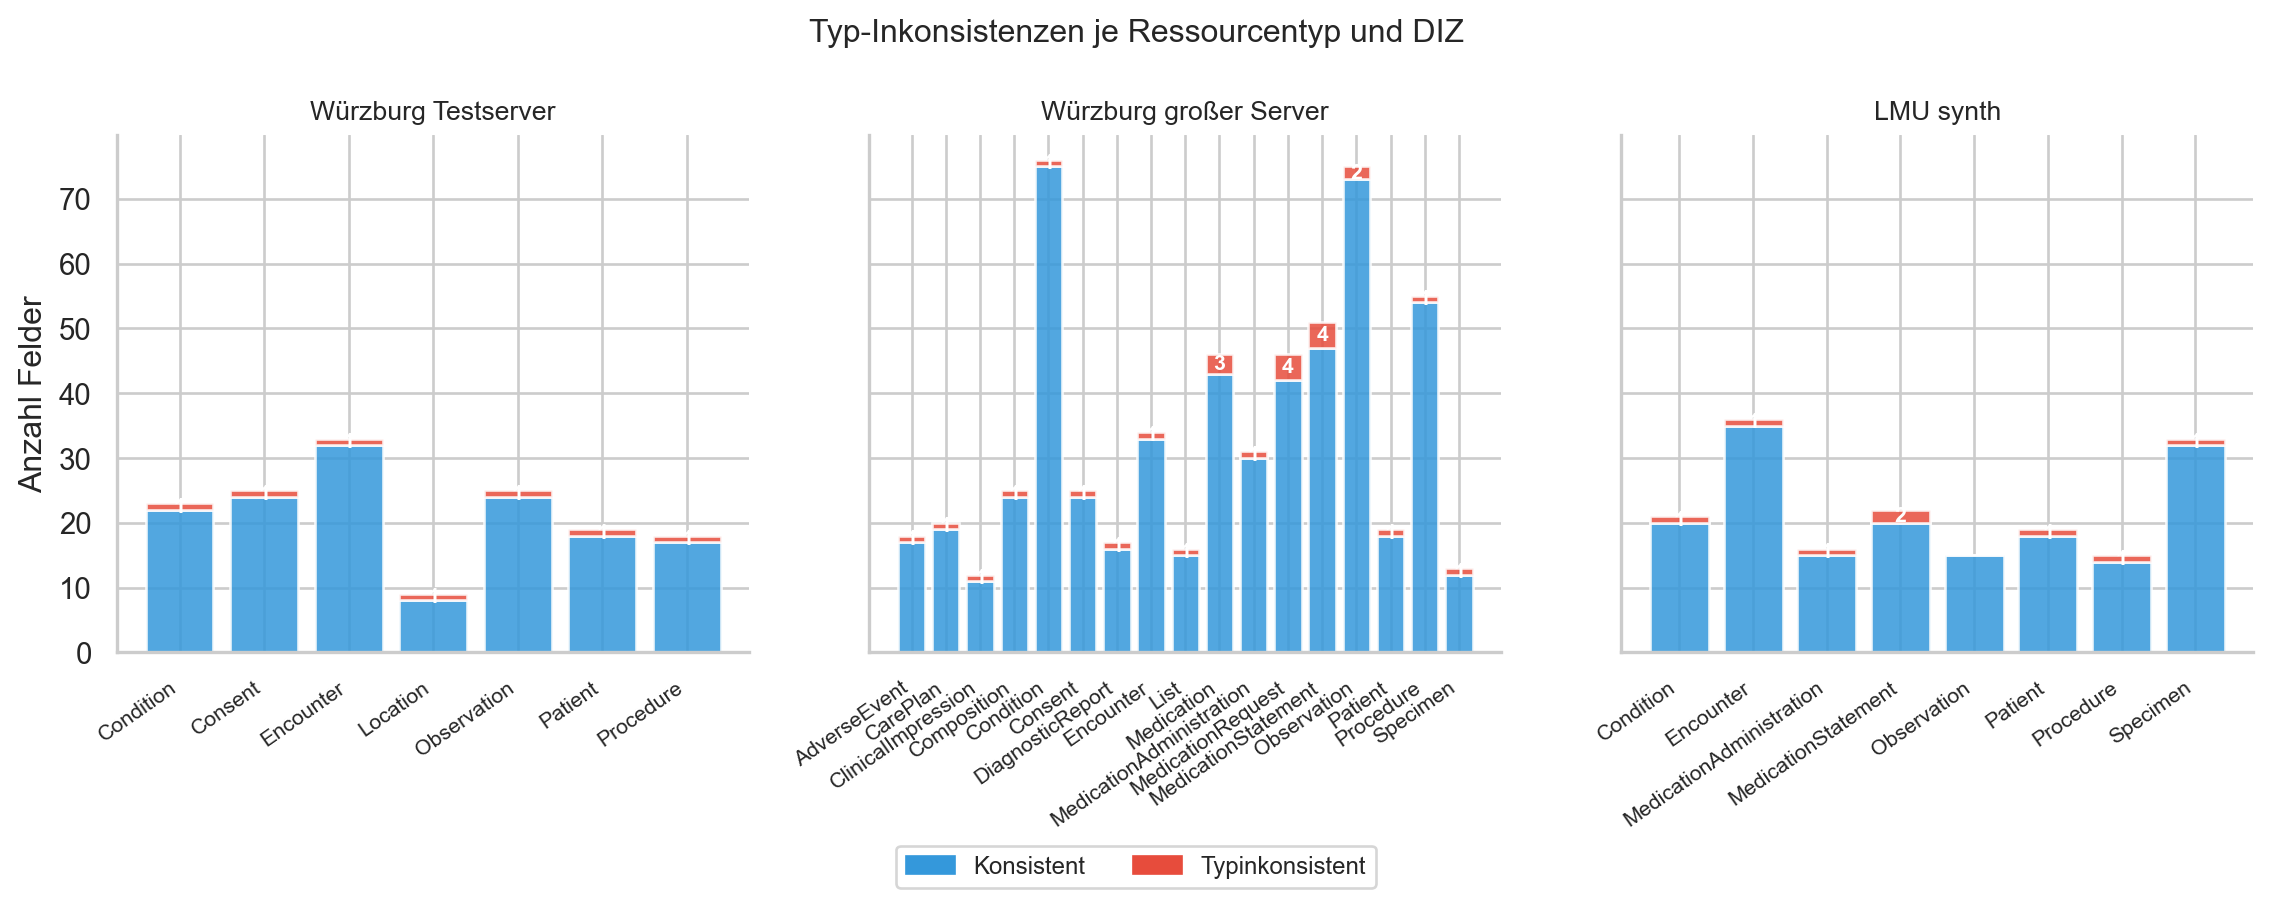


41 inkonsistente Felder:


,diz,resource_type,field_path,detected_python_types,presence_rate
0,Würzburg großer Server,AdverseEvent,AdverseEvent.meta.profile[],"array, string",1.000
1,Würzburg großer Server,CarePlan,CarePlan.meta.profile[],"array, string",1.000
2,Würzburg großer Server,ClinicalImpression,ClinicalImpression.meta.profile[],"array, string",1.000
3,Würzburg großer Server,Composition,Composition.meta.profile[],"array, string",1.000
4,LMU synth,Condition,Condition.meta.profile[],"array, string",1.000
5,Würzburg Testserver,Condition,Condition.meta.profile[],"array, string",1.000
6,Würzburg großer Server,Condition,Condition.meta.profile[],"array, string",1.000
7,Würzburg Testserver,Consent,Consent.meta.profile[],"array, string",1.000
8,Würzburg großer Server,Consent,Consent.meta.profile[],"array, string",1.000
9,Würzburg großer Server,DiagnosticReport,DiagnosticReport.meta.profile[],"array, string",1.000


In [24]:
# ── 9. Typ-Inkonsistenzen: gestapelter Balken pro DIZ ───────────────────
if not df_fields.empty and "type_inconsistency" in df_fields.columns:
    scalar_fields = df_fields[
        df_fields["_is_data_field"]
    ].copy()
    scalar_fields["type_inconsistency"] = scalar_fields["type_inconsistency"].astype(bool)

    inc_summary = (
        scalar_fields.groupby(["diz", "resource_type"])
        .agg(total=("field_path", "nunique"),
             inconsistent=("type_inconsistency", "sum"))
        .reset_index()
    )
    inc_summary["consistent"] = inc_summary["total"] - inc_summary["inconsistent"]

    n_diz = len(LOADED_DIZ)
    fig, axes = plt.subplots(1, n_diz, figsize=(max(7, n_diz * 4), 4.5), sharey=True)
    if n_diz == 1:
        axes = [axes]

    for ax, diz_name in zip(axes, LOADED_DIZ):
        sub = inc_summary[inc_summary["diz"] == diz_name].sort_values("resource_type")
        x = np.arange(len(sub))

        b1 = ax.bar(x, sub["consistent"], color="#3498db", alpha=0.85, label="Konsistent")
        b2 = ax.bar(x, sub["inconsistent"], bottom=sub["consistent"].values,
                    color="#e74c3c", alpha=0.85, label="Typinkonsistent")

        for bar, val, bot in zip(b2, sub["inconsistent"].values, sub["consistent"].values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bot + val / 2,
                        str(int(val)), ha="center", va="center",
                        fontsize=8, color="white", fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels(sub["resource_type"].tolist(), rotation=35, ha="right", size=8)
        ax.set_title(diz_name, size=10)
        ax.set_ylabel("Anzahl Felder" if diz_name == LOADED_DIZ[0] else "")
        sns.despine(ax=ax)

    handles = [
        mpatches.Patch(color="#3498db", label="Konsistent"),
        mpatches.Patch(color="#e74c3c", label="Typinkonsistent"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=2,
               bbox_to_anchor=(0.5, -0.04), fontsize=9)
    fig.suptitle("Typ-Inkonsistenzen je Ressourcentyp und DIZ", size=12)
    plt.tight_layout()
    plt.show()

    # Detailliste
    inc_fields = scalar_fields[scalar_fields["type_inconsistency"]][
        ["diz", "resource_type", "field_path", "detected_python_types", "presence_rate"]
    ].sort_values(["resource_type", "field_path", "diz"])

    if not inc_fields.empty:
        print(f"\n{len(inc_fields)} inkonsistente Felder:")
        display(inc_fields.reset_index(drop=True))
    else:
        print("Keine Typ-Inkonsistenzen gefunden.")
else:
    print("Spalte 'type_inconsistency' nicht gefunden.")

***
## 10. MI-I Profil-Versionierung

Vergleicht, welche Profile (inkl. Versionsnummer) die verschiedenen DIZ verwenden.  
Datenquelle: `*.meta.profile[]` aller Ressourcentypen.  
Eine Profil-URL folgt dem Schema `…/StructureDefinition/ProfilName|2025.0.2` — der Teil nach dem `|` ist die **Versionskennung**. Fehlt der `|`-Suffix, ist die Ressource ohne explizite Versionsangabe profiliert.

**Ausgaben:**
- **10a** — Profilübersicht je DIZ: dominante Version je (Ressourcentyp, Profil)-Kombination
- **10b** — Versionsabweichungen zwischen DIZ: (Ressourcentyp, Profil)-Paare, bei denen DIZ unterschiedliche Versionen nutzen  
- **10b2** — Intra-DIZ Versions-Mix: ein einzelnes DIZ nutzt mehrere Versionen desselben Profils gleichzeitig (z. B. unversionierte Altdaten + neue versionierte Daten)  
- **10d** — Profil × DIZ Heatmap: Version als Text, Farbe = Konsistenz

In [25]:
# ── 10. Profil-Extraktion ─────────────────────────────────────────────────

PROFILE_DOMAIN_MAP = [
    ("medizininformatik-initiative.de/fhir/core", "MII Core"),
    ("medizininformatik-initiative.de/fhir/ext",  "MII Ext"),
    ("medizininformatik-initiative.de/",          "MI-I sonstige"),
    ("gematik.de/fhir/isik",                      "ISiK (Gematik)"),
    ("kbv.de/",                                    "KBV"),
    ("hl7.org/",                                   "HL7"),
]

def _profile_domain(url: str) -> str:
    for pattern, label in PROFILE_DOMAIN_MAP:
        if pattern in url:
            return label
    return "Sonstige"


def extract_profiles(df: pd.DataFrame) -> pd.DataFrame:
    """
    Parst alle *.meta.profile[] Felder aus df_fields.
    Gibt eine Zeile pro (diz, resource_type, profile_url) zurück.
    Spalten: diz, resource_type, profile_url, base_url, profile_name,
             version, count, total_resources, share, domain
    """
    rows = []
    mask = df["field_path"].str.endswith(".meta.profile[]", na=False)
    for _, frow in df[mask].iterrows():
        tv = parse_top_values(frow.get("top_values", ""))
        total = int(frow.get("total_resources", 0) or 1)
        for url, cnt in tv.items():
            if "|" in url:
                base_url, version = url.rsplit("|", 1)
            else:
                base_url, version = url, "(ohne Version)"
            profile_name = base_url.rstrip("/").split("/")[-1]
            rows.append(dict(
                diz=frow["diz"],
                resource_type=frow["resource_type"],
                profile_url=url,
                base_url=base_url,
                profile_name=profile_name,
                version=version,
                count=int(cnt),
                total_resources=total,
                share=int(cnt) / total,
                domain=_profile_domain(url),
            ))
    return pd.DataFrame(rows) if rows else pd.DataFrame()


df_profiles = extract_profiles(df_fields)

if df_profiles.empty:
    print("⚠️  Keine Profil-Daten gefunden (meta.profile[] fehlt in den Felddaten).")
else:
    n_profiles  = df_profiles["base_url"].nunique()
    n_versions  = df_profiles["version"].nunique()
    n_resources = df_profiles["count"].sum()
    print(f"✅ Profil-Daten: {len(df_profiles):,} Einträge | "
          f"{n_profiles} eindeutige Profil-URLs | "
          f"{n_versions} Versionsstrings | "
          f"{n_resources:,} Ressourcen gesamt\n")

    overview = (
        df_profiles
        .groupby(["domain", "base_url"])
        .agg(
            Ressourcen=("count", "sum"),
        Versionen=("version", lambda s: ", ".join(sorted(s.unique()))),
            DIZ=("diz", lambda s: ", ".join(sorted(s.unique()))),
        )
        .sort_values("Ressourcen", ascending=False)
        .head(25)
        .reset_index()
        .rename(columns={"domain": "Domain", "base_url": "Profil-URL"})
    )
    display(overview)

✅ Profil-Daten: 74 Einträge | 50 eindeutige Profil-URLs | 9 Versionsstrings | 348,447,135 Ressourcen gesamt



,Domain,Profil-URL,Ressourcen,Versionen,DIZ
0,MII Core,https://www.medizininformatik-initiative.de/fhir/core/modul-labor/StructureD...,92041531,"(ohne Version), 2025.0.2","Würzburg Testserver, Würzburg großer Server"
1,MII Core,https://www.medizininformatik-initiative.de/fhir/core/modul-fall/StructureDe...,27011036,"(ohne Version), 2025.0.0","LMU synth, Würzburg Testserver, Würzburg großer Server"
2,MII Ext,https://www.medizininformatik-initiative.de/fhir/ext/modul-icu/StructureDefi...,21414334,2026.0.0,Würzburg großer Server
3,MII Ext,https://www.medizininformatik-initiative.de/fhir/ext/modul-icu/StructureDefi...,20295543,2026.0.0,"Würzburg Testserver, Würzburg großer Server"
4,MII Core,https://www.medizininformatik-initiative.de/fhir/core/modul-medikation/Struc...,20254675,"(ohne Version), 2025.0.0, 2026.0.0","LMU synth, Würzburg großer Server"
5,ISiK (Gematik),https://gematik.de/fhir/isik/StructureDefinition/sd-mii-icu-o2saettigung-im-...,19962261,4.0.0,Würzburg großer Server
6,MII Core,https://www.medizininformatik-initiative.de/fhir/core/modul-diagnose/Structu...,17264018,"(ohne Version), 2024.0.0, 2025.0.0","LMU synth, Würzburg Testserver, Würzburg großer Server"
7,MII Core,https://www.medizininformatik-initiative.de/fhir/core/modul-medikation/Struc...,16369243,"2025.0.0, 2026.0.0","LMU synth, Würzburg großer Server"
8,MII Core,https://www.medizininformatik-initiative.de/fhir/core/modul-prozedur/Structu...,13066798,"(ohne Version), 2025.0.0","LMU synth, Würzburg Testserver, Würzburg großer Server"
9,MII Core,https://www.medizininformatik-initiative.de/fhir/core/modul-medikation/Struc...,12708968,2026.0.0,Würzburg großer Server


In [26]:
# ── 10a. Profilübersicht: dominante Version je DIZ ────────────────────────
# Eine Zeile je (Ressourcentyp, Profil), eine Spalte je DIZ.
# Zellinhalt = "dominante Version  (Ressourcenanzahl)"

if not df_profiles.empty:
    dom = (
        df_profiles
        .sort_values("count", ascending=False)
        .groupby(["diz", "resource_type", "base_url", "profile_name", "domain"])
        .agg(version=("version", "first"), count=("count", "sum"))
        .reset_index()
    )
    dom["cell"] = dom["version"] + "  (" + dom["count"].apply(lambda x: f"{x:,}") + ")"

    pivot_12a = (
        dom
        .pivot_table(
            index=["resource_type", "profile_name", "domain"],
            columns="diz",
            values="cell",
            aggfunc="first",
        )
        .reindex(columns=LOADED_DIZ)
    )
    pivot_12a.columns.name = None
    pivot_12a = pivot_12a.fillna("—").reset_index()

    print(f"12a — {len(pivot_12a)} (Ressourcentyp, Profil)-Kombinationen\n")

    def _grey_missing(col):
        return ["color: #bbb; font-style: italic" if v == "—" else "" for v in col]

    display(
        pivot_12a.style
        .set_caption("Dominante Profilversion je DIZ  ·  [Version  (Ressourcenanzahl)]")
        .apply(_grey_missing, subset=LOADED_DIZ)
    )
else:
    print("Keine Profildaten.")

12a — 50 (Ressourcentyp, Profil)-Kombinationen



,resource_type,profile_name,domain,Würzburg Testserver,Würzburg großer Server,LMU synth
0,AdverseEvent,mii-pr-onko-nebenwirkung-adverse-event,MII Ext,—,"2026.0.0 (64,364)",—
1,CarePlan,mii-pr-onko-tumorkonferenz,MII Ext,—,"2026.0.0 (96,105)",—
2,ClinicalImpression,mii-pr-seltene-clinical-impression,MII Ext,—,"2026.0.0 (46,000)",—
3,Composition,mii-pr-bildgebung-semistrukt-befundbericht,MII Ext,—,"2026.0.0 (2,151,484)",—
4,Condition,Diagnose,MII Core,"2025.0.0 (3,604,536)","2024.0.0 (9,659,519)","2025.0.0 (3,999,963)"
5,Condition,mii-pr-onko-diagnose-primaertumor,MII Ext,—,"2026.0.0 (53,412)",—
6,Condition,mii-pr-onko-fruehere-tumorerkrankung,MII Ext,—,"2026.0.0 (6,862)",—
7,Condition,mii-pr-seltene-clinical-diagnosis,MII Ext,—,"2026.0.0 (61,009)",—
8,Condition,mii-pr-seltene-symptom-condition,MII Ext,—,"2026.0.0 (3,283)",—
9,Consent,mii-pr-consent-einwilligung,MI-I sonstige,2025.0.4 (276),"(ohne Version) (24,846)",—


In [27]:
# ── 10b. Versionsabweichungen zwischen DIZ ────────────────────────────────
# Zeigt (Ressourcentyp, Profil)-Paare, bei denen verschiedene DIZ
# unterschiedliche Versionen des gleichen Profils verwenden.

if not df_profiles.empty and len(LOADED_DIZ) > 1:
    dom_ver = (
        df_profiles
        .sort_values("count", ascending=False)
        .groupby(["diz", "resource_type", "base_url", "profile_name"])["version"]
        .first()
        .reset_index()
    )

    ver_pivot = (
        dom_ver
        .pivot_table(
            index=["resource_type", "base_url", "profile_name"],
            columns="diz",
            values="version",
            aggfunc="first",
        )
        .reindex(columns=LOADED_DIZ)
        .reset_index()
    )

    diz_cols = [c for c in LOADED_DIZ if c in ver_pivot.columns]
    has_2    = ver_pivot[diz_cols].notna().sum(axis=1) >= 2

    def _differs(row):
        vals = [row[c] for c in diz_cols if pd.notna(row[c])]
        return len(set(vals)) > 1

    divergent = ver_pivot[has_2 & ver_pivot.apply(_differs, axis=1)].copy()
    divergent = divergent.drop_duplicates().reset_index(drop=True)

    if divergent.empty:
        print("✅ Keine Versionsabweichungen gefunden — alle DIZ verwenden "
              "die gleiche Profilversion für gemeinsame Ressourcentypen.")
    else:
        print(f"⚠️  {len(divergent)} Profil(e) mit Versionsabweichungen:\n")

        def _highlight_div(row):
            styles = [""] * len(row)
            for i, col in enumerate(row.index):
                if col not in diz_cols:
                    continue
                if pd.isna(row[col]):
                    styles[i] = "color: #bbb; font-style: italic"
                    continue
                present = [row[c] for c in diz_cols if pd.notna(row[c])]
                if len(set(present)) > 1:
                    styles[i] = "background-color: #ffe0b2; font-weight: bold"
            return styles

        display(
            divergent.fillna("—").style
            .apply(_highlight_div, axis=1)
            .set_caption(
                "Versionsabweichungen  ·  Orange = unterschiedliche Version zwischen DIZ"
            )
        )

        # Zusätzlich: Ressourcenanteil pro Version je abweichendem Profil
        print("\nRessourcenverteilung nach Version für abweichende Profile:")
        for _, row in divergent.iterrows():
            rt, base_url = row["resource_type"], row["base_url"]
            sub = df_profiles[
                (df_profiles["resource_type"] == rt) &
                (df_profiles["base_url"] == base_url)
            ][["diz", "version", "count", "share"]].sort_values("count", ascending=False)
            print(f"\n  {rt}  ·  {base_url.split('/')[-1]}")
            display(sub.reset_index(drop=True))
else:
    print("Mindestens 2 DIZ erforderlich für Versionsvergleich.")

⚠️  7 Profil(e) mit Versionsabweichungen:



diz,resource_type,base_url,profile_name,Würzburg Testserver,Würzburg großer Server,LMU synth
0,Condition,https://www.medizininformatik-initiative.de/fhir/core/modul-diagnose/StructureDefinition/Diagnose,Diagnose,2025.0.0,2024.0.0,2025.0.0
1,Consent,https://www.medizininformatik-initiative.de/fhir/modul-consent/StructureDefinition/mii-pr-consent-einwilligung,mii-pr-consent-einwilligung,2025.0.4,(ohne Version),—
2,MedicationAdministration,https://www.medizininformatik-initiative.de/fhir/core/modul-medikation/StructureDefinition/MedicationAdministration,MedicationAdministration,—,2026.0.0,2025.0.0
3,MedicationStatement,https://www.medizininformatik-initiative.de/fhir/core/modul-medikation/StructureDefinition/MedicationStatement,MedicationStatement,—,2026.0.0,2025.0.0
4,Observation,https://www.medizininformatik-initiative.de/fhir/core/modul-labor/StructureDefinition/ObservationLab,ObservationLab,2025.0.2,(ohne Version),—
5,Patient,https://www.medizininformatik-initiative.de/fhir/core/modul-person/StructureDefinition/PatientPseudonymisiert,PatientPseudonymisiert,2025.0.1,(ohne Version),2025.0.0
6,Procedure,https://www.medizininformatik-initiative.de/fhir/core/modul-prozedur/StructureDefinition/Procedure,Procedure,2025.0.0,(ohne Version),2025.0.0



Ressourcenverteilung nach Version für abweichende Profile:

  Condition  ·  Diagnose


,diz,version,count,share
0,Würzburg großer Server,2024.0.0,9081172,0.928
1,LMU synth,2025.0.0,3999963,1.000
2,Würzburg Testserver,2025.0.0,3604536,1.000
3,Würzburg großer Server,2025.0.0,484039,0.049
4,Würzburg großer Server,(ohne Version),94308,0.010



  Consent  ·  mii-pr-consent-einwilligung


...

,diz,version,count,share
0,Würzburg großer Server,(ohne Version),83290478,0.404
1,Würzburg Testserver,2025.0.2,4527727,1.000
2,Würzburg großer Server,2025.0.2,4223326,0.020



  Patient  ·  PatientPseudonymisiert


,diz,version,count,share
0,LMU synth,2025.0.0,4100747,1.000
1,Würzburg Testserver,2025.0.1,1766849,1.000
2,Würzburg großer Server,(ohne Version),1485923,0.953
3,Würzburg großer Server,2025.0.1,73302,0.047



  Procedure  ·  Procedure


,diz,version,count,share
0,Würzburg großer Server,(ohne Version),6165502,0.291
1,LMU synth,2025.0.0,3997336,1.000
2,Würzburg Testserver,2025.0.0,2571064,0.292
3,Würzburg großer Server,2025.0.0,332896,0.016


In [28]:
# ── 10b2. Intra-DIZ Versions-Mix: ein DIZ, mehrere Versionen des gleichen Profils ──
# Tritt auf wenn ein Server Ressourcen unter verschiedenen Versionen des gleichen
# Profils abgelegt hat (z.B. Altdaten unversioniert + neue Daten mit |2025.0.2).

if not df_profiles.empty:
    version_counts = (
        df_profiles
        .groupby(["diz", "resource_type", "base_url", "profile_name"])["version"]
        .nunique()
        .reset_index(name="n_versions")
    )
    mixed = version_counts[version_counts["n_versions"] > 1].copy()

    if mixed.empty:
        print("✅ Kein intra-DIZ Versions-Mix — jedes DIZ nutzt je Profil eine einzige Version.")
    else:
        print(f"⚠️  {len(mixed)} (DIZ, Ressourcentyp, Profil)-Kombinationen mit Versions-Mix:\n")
        for _, m_row in mixed.iterrows():
            detail = df_profiles[
                (df_profiles["diz"]           == m_row["diz"]) &
                (df_profiles["resource_type"] == m_row["resource_type"]) &
                (df_profiles["base_url"]      == m_row["base_url"])
            ][["version", "count", "share"]].sort_values("count", ascending=False)
            print(f"  {m_row['diz']}  ·  {m_row['resource_type']}  ·  {m_row['profile_name']}")
            for _, d in detail.iterrows():
                bar = "█" * int(d["share"] * 30)
                print(f"    {d['version']:30s}  {d['count']:>12,}  ({d['share']:5.1%})  {bar}")
            print()

⚠️  8 (DIZ, Ressourcentyp, Profil)-Kombinationen mit Versions-Mix:

  Würzburg großer Server  ·  Condition  ·  Diagnose
    2024.0.0                           9,081,172  (92.8%)  ███████████████████████████
    2025.0.0                             484,039  ( 4.9%)  █
    (ohne Version)                        94,308  ( 1.0%)  

  Würzburg großer Server  ·  Consent  ·  mii-pr-consent-einwilligung
    (ohne Version)                        23,038  (92.7%)  ███████████████████████████
    2025.0.4                               1,808  ( 7.3%)  ██

  Würzburg großer Server  ·  Encounter  ·  KontaktGesundheitseinrichtung
    2025.0.0                          16,904,972  (82.2%)  ████████████████████████
    (ohne Version)                     3,667,631  (17.8%)  █████

  Würzburg großer Server  ·  MedicationAdministration  ·  MedicationAdministration
    2026.0.0                          17,616,909  (99.9%)  █████████████████████████████
    (ohne Version)                        23,074  ( 0.1%)

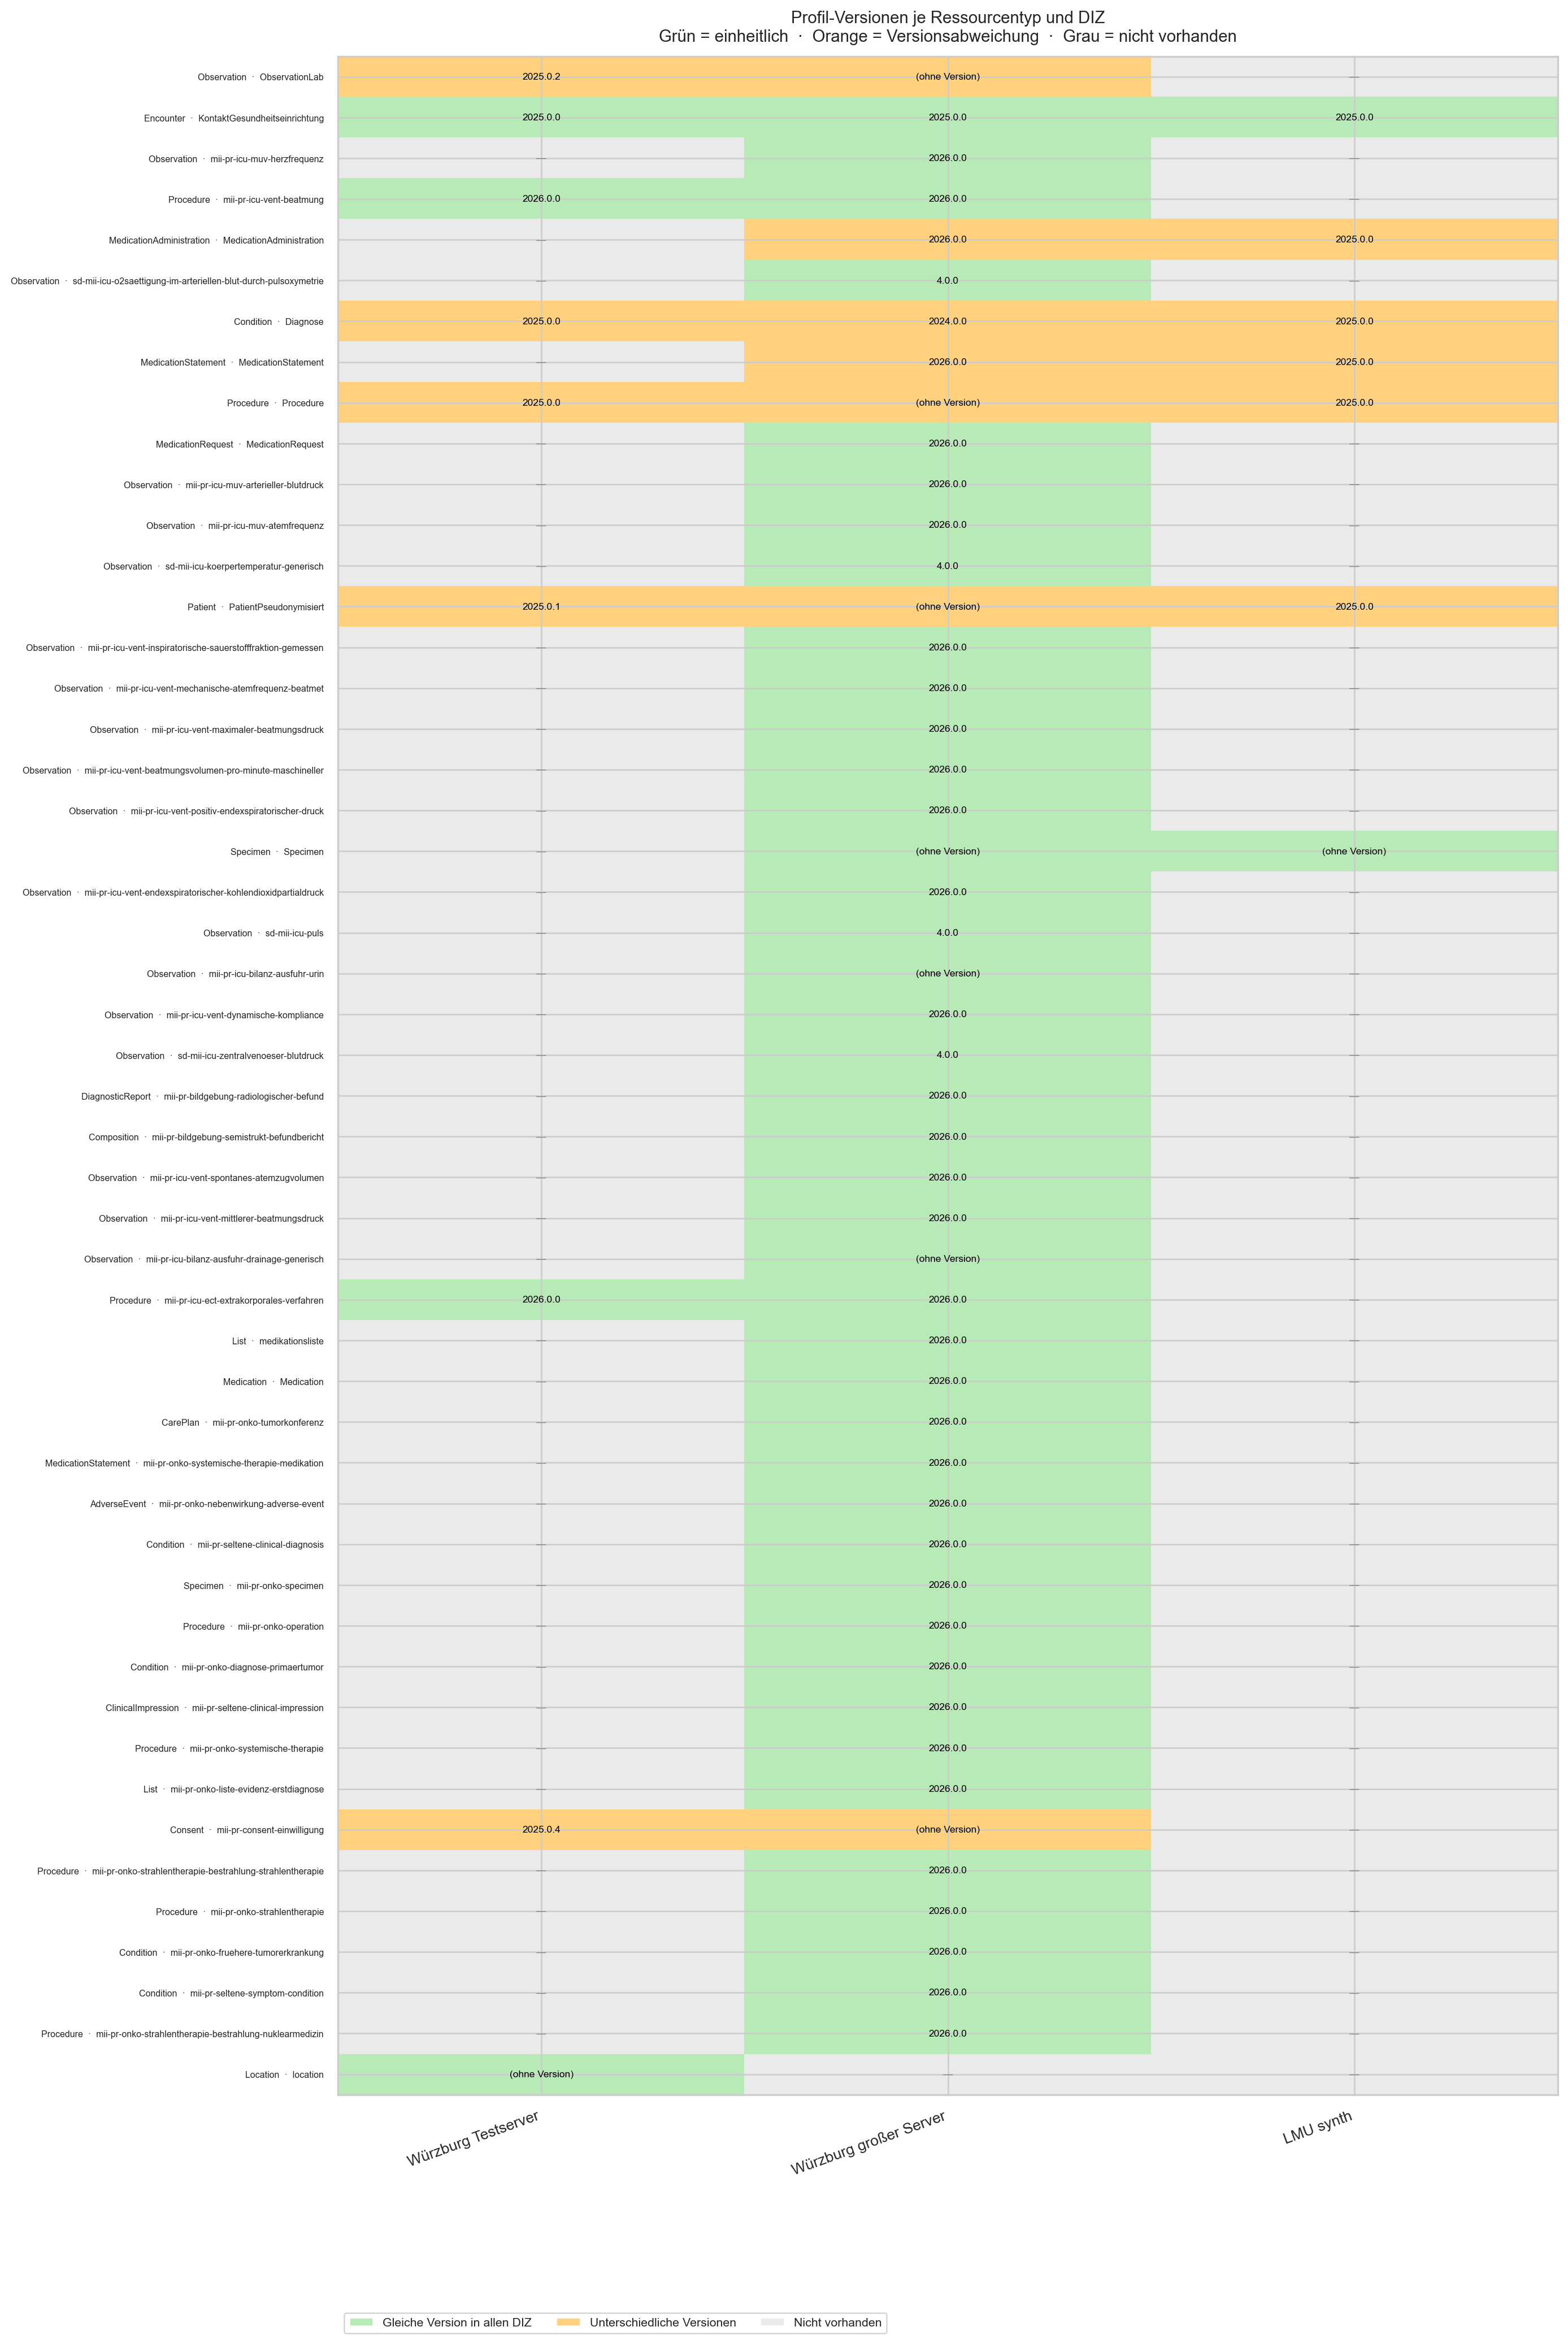

In [29]:
# ── 10d. Profil × DIZ Heatmap (Matplotlib) ───────────────────────────────
# Zeilen = (Ressourcentyp, Profilname), Spalten = DIZ.
# Text = dominante Version, Farbe = Konsistenzstatus.
# Grün = alle vorhandenen DIZ nutzen die gleiche Version.
# Orange = unterschiedliche Versionen zwischen DIZ.
# Hellgrau = Profil für dieses DIZ nicht vorhanden.

MAX_ROWS_HEATMAP = 60  # bei sehr vielen Profilen kürzen

if not df_profiles.empty and len(LOADED_DIZ) > 1:
    dom_hm = (
        df_profiles
        .sort_values("count", ascending=False)
        .groupby(["diz", "resource_type", "base_url", "profile_name"])
        .agg(version=("version", "first"), count=("count", "sum"))
        .reset_index()
    )

    # Zeilen-Reihenfolge: nach Gesamtanzahl absteigend
    row_order = (
        dom_hm.groupby(["resource_type", "profile_name"])["count"]
        .sum()
        .sort_values(ascending=False)
        .head(MAX_ROWS_HEATMAP)
        .index.tolist()   # list of (resource_type, profile_name) tuples
    )

    n_rows = len(row_order)
    n_cols = len(LOADED_DIZ)

    # Matrizen aufbauen
    text_mat  = np.full((n_rows, n_cols), "", dtype=object)
    color_mat = np.zeros((n_rows, n_cols, 4))
    color_mat[:] = [0.92, 0.92, 0.92, 1.0]  # default: hellgrau

    GREEN  = [0.72, 0.92, 0.72, 1.0]
    ORANGE = [1.00, 0.82, 0.50, 1.0]

    for i, (rt, pname) in enumerate(row_order):
        sub = dom_hm[(dom_hm["resource_type"] == rt) & (dom_hm["profile_name"] == pname)]
        present = {}
        for j, diz_name in enumerate(LOADED_DIZ):
            row_d = sub[sub["diz"] == diz_name]
            if not row_d.empty:
                ver = row_d.iloc[0]["version"]
                text_mat[i, j] = ver
                present[j] = ver

        if not present:
            continue
        versions = list(present.values())
        fill = GREEN if len(set(versions)) == 1 else ORANGE
        for j in present:
            color_mat[i, j] = fill

    # Plot
    cell_h  = max(0.38, min(0.6, 14 / n_rows))
    fig_h   = max(5, n_rows * cell_h + 2.5)
    fig_w   = max(8, n_cols * 3.2 + 5)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.imshow(color_mat, aspect="auto", interpolation="none")

    for i in range(n_rows):
        for j in range(n_cols):
            txt = text_mat[i, j] if text_mat[i, j] else "—"
            c   = "grey" if txt == "—" else "black"
            ax.text(j, i, txt, ha="center", va="center",
                    fontsize=max(6.5, min(8.5, 80 / n_rows)), color=c)

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(LOADED_DIZ, rotation=20, ha="right", fontsize=10)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(
        [f"{rt}  ·  {pn}" for rt, pn in row_order],
        fontsize=max(6, min(8.5, 80 / n_rows))
    )
    ax.set_title(
        "Profil-Versionen je Ressourcentyp und DIZ\n"
        "Grün = einheitlich  ·  Orange = Versionsabweichung  ·  Grau = nicht vorhanden",
        fontsize=11, pad=10
    )

    # Legende
    from matplotlib.patches import Patch as _Patch
    legend_els = [
        _Patch(facecolor=GREEN,  label="Gleiche Version in allen DIZ"),
        _Patch(facecolor=ORANGE, label="Unterschiedliche Versionen"),
        _Patch(facecolor=[0.92, 0.92, 0.92, 1.0], label="Nicht vorhanden"),
    ]
    ax.legend(handles=legend_els, loc="lower left",
              bbox_to_anchor=(0.0, -0.12), ncol=3, fontsize=8)

    plt.tight_layout()
    plt.show()

    if n_rows == MAX_ROWS_HEATMAP and df_profiles[["resource_type","profile_name"]].drop_duplicates().shape[0] > MAX_ROWS_HEATMAP:
        shown = df_profiles[["resource_type","profile_name"]].drop_duplicates().shape[0]
        print(f"ℹ️  Heatmap zeigt die {MAX_ROWS_HEATMAP} häufigsten von {shown} Profil-Kombinationen.")
elif len(LOADED_DIZ) < 2:
    print("Mindestens 2 DIZ erforderlich.")
else:
    print("Keine Profildaten.")

***
## 11. Matplotlib / Seaborn — Statische Grafiken

Ergänzende Visualisierungen mit Matplotlib und Seaborn — geeignet für Berichte und Druckexporte.

### 11a. Radar-Chart — Ø Presence Rate je Ressourcentyp

Zeigt auf einen Blick, welche Ressourcentypen wie vollständig befüllt sind. Durchschnitt über alle Datenfelder (`_is_data_field = True`). Quelle: `*_fields.csv` → `presence_rate`.

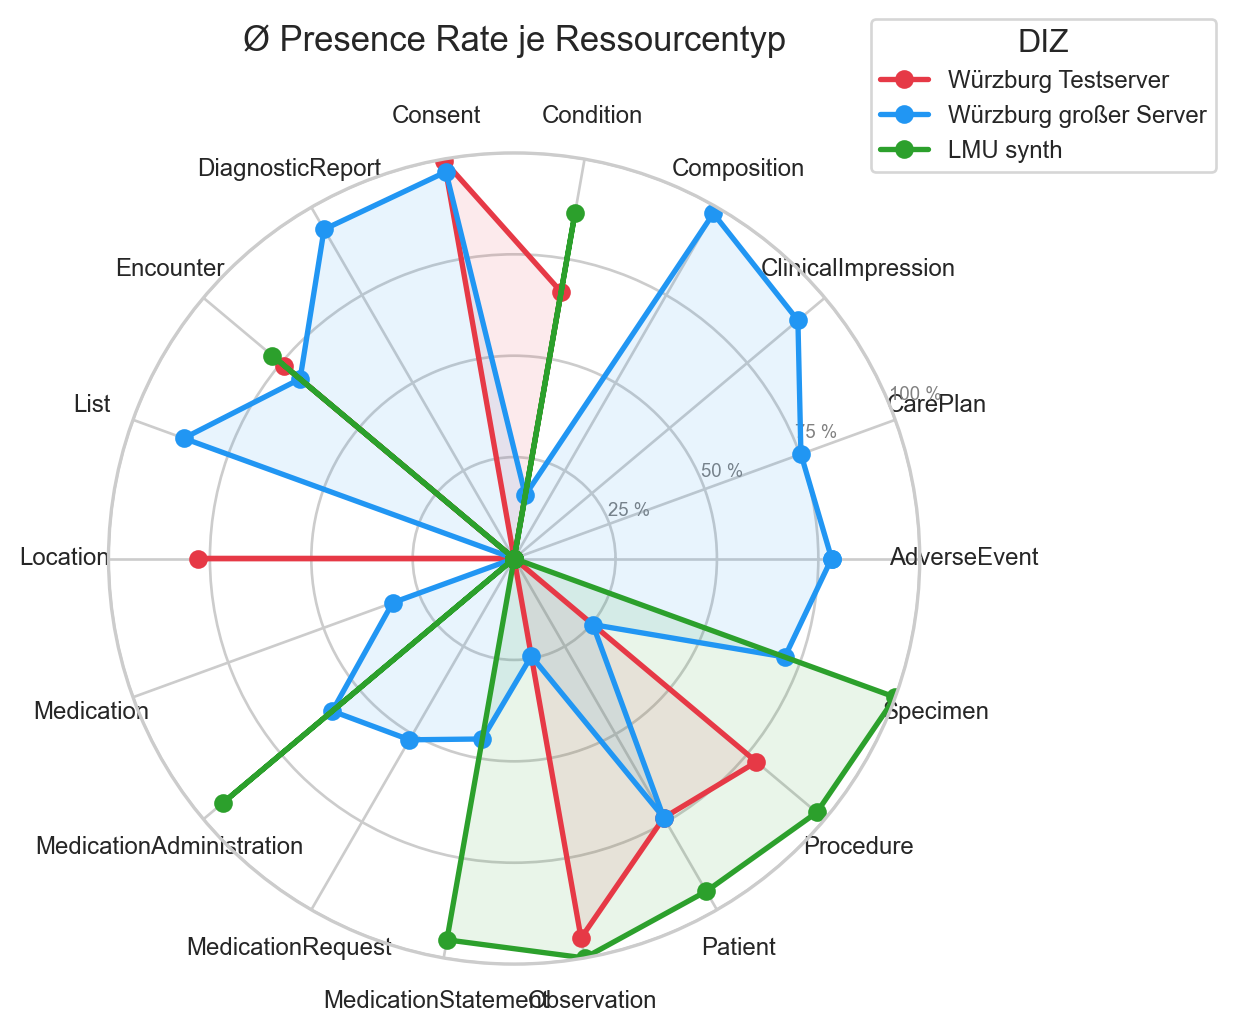

In [30]:
# ── 11a. Radar-Chart: Ø Presence Rate je Ressourcentyp & DIZ ──────────────
if not df_fields.empty and ALL_RT:
    scalar_fields = df_fields[
        df_fields["_is_data_field"]
    ].copy()

    avg_pr = (
        scalar_fields.groupby(["diz", "resource_type"])["presence_rate"]
        .mean()
        .unstack("resource_type")
        .reindex(columns=ALL_RT)
        .fillna(0)
    )

    N = len(ALL_RT)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for diz_name in LOADED_DIZ:
        if diz_name not in avg_pr.index:
            continue
        values = avg_pr.loc[diz_name].tolist()
        values += values[:1]
        ax.plot(angles, values, "o-", linewidth=2, label=diz_name,
                color=MPL_COLOR_MAP[diz_name])
        ax.fill(angles, values, alpha=0.1, color=MPL_COLOR_MAP[diz_name])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(ALL_RT, size=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["25 %", "50 %", "75 %", "100 %"], size=7, color="grey")
    ax.set_title("Ø Presence Rate je Ressourcentyp", size=13, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.38, 1.18), title="DIZ", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Keine Felddaten verfügbar.")

### 11b. Verteilung der Presence Rates — Histogramm + KDE

Wie viele Felder sind sehr selten befüllt, wie viele immer? Linker Peak = viele optionale Felder, rechter Peak = viele Pflichtfelder. Quelle: `*_fields.csv` → `presence_rate`.

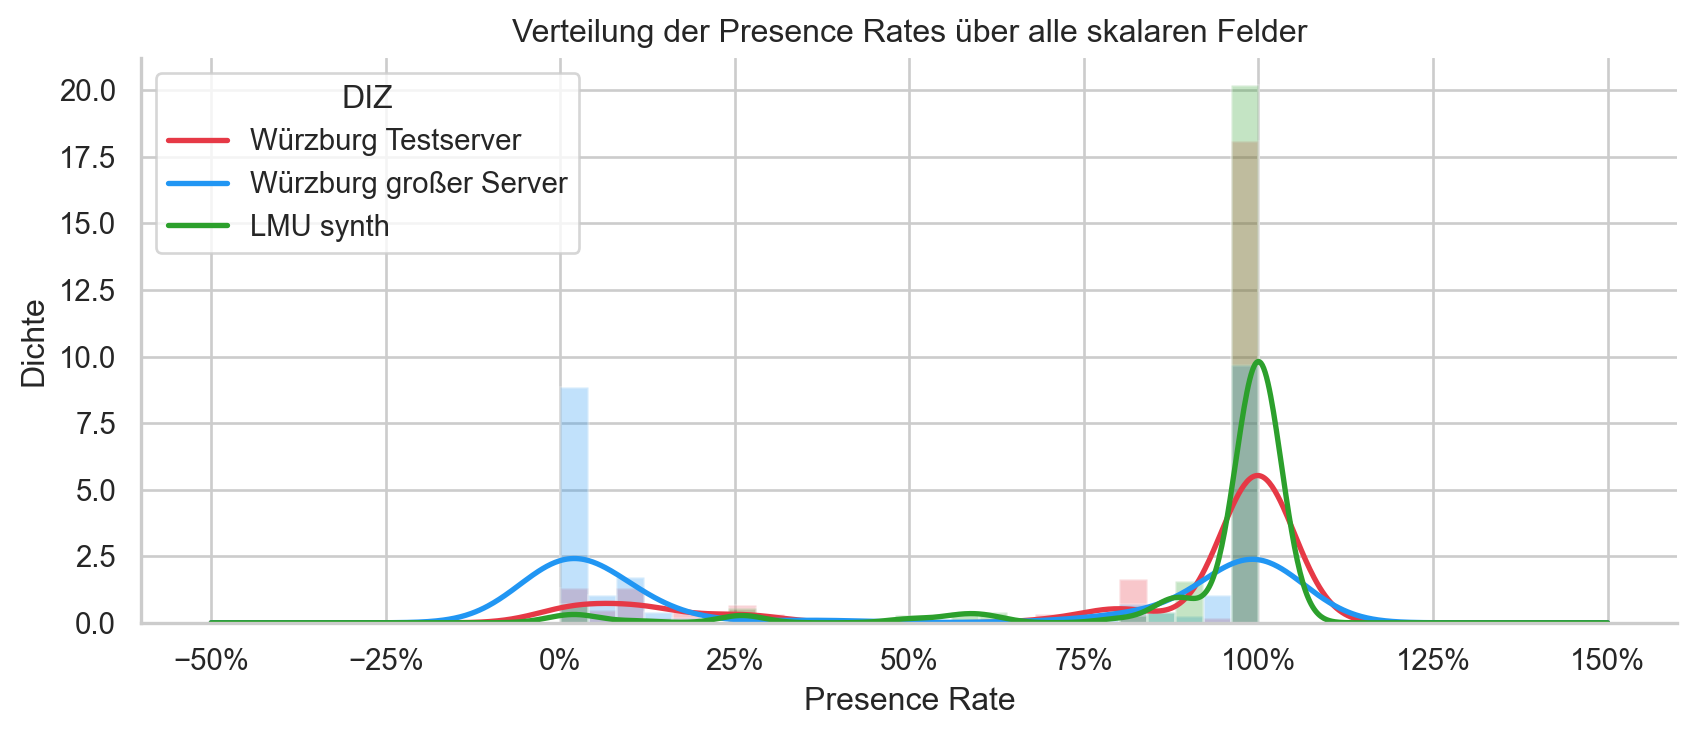

In [31]:
# ── 11c. Presence-Rate-Verteilung: Histogramm + KDE ───────────────────────
if not df_fields.empty:
    scalar_fields = df_fields[
        df_fields["_is_data_field"]
    ].copy()

    fig, ax = plt.subplots(figsize=(9, 4))

    for diz_name in LOADED_DIZ:
        pr = scalar_fields[scalar_fields["diz"] == diz_name]["presence_rate"].dropna()
        ax.hist(pr, bins=25, range=(0, 1), alpha=0.28,
                color=MPL_COLOR_MAP[diz_name], density=True)
        pr.plot.kde(ax=ax, bw_method=0.15, color=MPL_COLOR_MAP[diz_name],
                    linewidth=2, label=diz_name)

    ax.set_xlabel("Presence Rate")
    ax.set_ylabel("Dichte")
    ax.set_title("Verteilung der Presence Rates über alle skalaren Felder")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.legend(title="DIZ")
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("Keine Felddaten verfügbar.")

::: {.content-hidden}
***
## 12. Export

Zusammengefasste Divergenztabelle als CSV speichern.
:::


In [32]:
EXPORT_PATH = Path("../results") / datetime.now().strftime("%Y%m%d_%H_%M")
EXPORT_PATH.mkdir(parents=True, exist_ok=True)

exported = []

# Presence-Rate-Pivot (alle Felder)
if not df_fields.empty:
    scalar_all = df_fields[
        df_fields["_is_data_field"]
    ]
    pivot_all = scalar_all.pivot_table(
        index=["resource_type", "field_path"], columns="diz",
        values="presence_rate", aggfunc="first"
    ).reindex(columns=LOADED_DIZ).reset_index()
    pivot_all.columns.name = None
    out = EXPORT_PATH / "presence_rate_all_fields.csv"
    pivot_all.to_csv(out, index=False)
    exported.append(out)

# Divergenztabelle
if 'df_divergence' in dir() and not df_divergence.empty:
    out = EXPORT_PATH / "field_divergence.csv"
    df_divergence.to_csv(out, index=False)
    exported.append(out)

# Data Quality
if not df_quality.empty:
    out = EXPORT_PATH / "data_quality_comparison.csv"
    df_quality.to_csv(out, index=False)
    exported.append(out)

# Kardinality
if not df_card.empty:
    out = EXPORT_PATH / "cardinality_comparison.csv"
    df_card.to_csv(out, index=False)
    exported.append(out)

# MI-I Profil-Versionierung (Section 12)
if 'df_profiles' in dir() and not df_profiles.empty:
    out = EXPORT_PATH / "mii_profile_versions.csv"
    df_profiles.to_csv(out, index=False)
    exported.append(out)

    # Pivot: dominante Version je (resource_type, profile_name) x diz
    if 'dom' in dir():
        pv = dom.pivot_table(
            index=["resource_type", "profile_name", "base_url", "domain"],
            columns="diz", values="version", aggfunc="first"
        ).reindex(columns=LOADED_DIZ).reset_index()
        pv.columns.name = None
        out = EXPORT_PATH / "mii_profile_version_pivot.csv"
        pv.to_csv(out, index=False)
        exported.append(out)

print("Exportiert:")
for p in exported:
    print(f"  {p}")

Exportiert:
  ../results/20260805_15_06/presence_rate_all_fields.csv
  ../results/20260805_15_06/field_divergence.csv
  ../results/20260805_15_06/data_quality_comparison.csv
  ../results/20260805_15_06/cardinality_comparison.csv
  ../results/20260805_15_06/mii_profile_versions.csv
  ../results/20260805_15_06/mii_profile_version_pivot.csv
